In [1]:
import os
os.environ['PYTENSOR_FLAGS'] = 'cxx='
import gzip
# import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import download as dwnld
# import os
import dataretrieval.waterdata as waterdata
from pathlib import Path
import utilities as util

# import package to reload utilities
import importlib
importlib.reload(util)

os.environ['API_USGS_PAT'] = 'lpK2Fw6n4cZpD28LUAxmvwhluFrhyyohhlTPbV7m'

data_dir = Path().cwd().parent / 'data'
swot_path = data_dir / 'usgs_swot_data/willamette_reach_id_swot_values.csv'
precip_path = data_dir / 'usgs_mrms_data/willamette_hierarchical_MRMS_{var_name}.csv'
start_time = '2023-01-01T00:00:00Z'
end_time = '2026-03-01T00:00:00Z'

In [2]:
# Get shapefile of nodes/reach
sword_path = "/Users/masa6503/repos/swot-precip-validation/data/na_sword_nodes_v17b_pnw.gpkg"
sword_gdf = gpd.read_file(sword_path)

# Retrieve active stations and associated nodes
stations = util.retrieve_stations()
active_ids = util.retrieve_active_stations(list('USGS-'+stations['usgs_site_no']))
relevant_stations = stations[("USGS-"+stations['usgs_site_no']).isin(active_ids)]
node_ids = relevant_stations['node_id'].unique()

# For the purposes of this notebook, we will focus on the Willamette reach and the Albany gage
willamette_node_id = '78220000200081'
willamette_reach_id = '78220000201'
albany_gage_id = "USGS-14174000"
reach_node_ids=sword_gdf[sword_gdf['reach_id'] == int(willamette_reach_id)]['node_id'].values


In [ ]:
# Retrieve swot data
# Pull all Willamette node data
fields = [
    # Index
    'node_id',
    'time_str',
    # Measurements
    'wse',
    'width',
    'area_total',
    # Quality -- to filter
    'node_q_b', # Not far or near swath (bits 13 + 14 set)
    'ice_clim_f', # Not ice (== 0)
    'xovr_cal_q', # Not bad xover (< 2)
    'p_dam_id', # Affected by dam
    'node_q',
    # Possibly affected by rain
    'dark_frac', 'n_good_pix', # Were measurements made
    'lat', 'lon', 'lat_u', 'lon_u', # Location + uncertainties
    'rdr_sig0', 'rdr_sig0_u', 'rdr_pol', # Backscatter coefficient
    'dry_trop_c', 'wet_trop_c', 'iono_c', 'xovr_cal_c', # Corrections
    'p_wse', 'p_wse_var', 'p_width', 'p_wid_var', # Prior estimages
]

fetch_hydrocron_study = (
    lambda node_id: dwnld.fetch_hydrocron_node(node_id, start_time, end_time, fields)
)

swot_ts_df_list = []
with ThreadPoolExecutor(max_workers=10) as executor:
    # Submit all tasks
    futures = [executor.submit(fetch_hydrocron_study, node_id) 
            for node_id in reach_node_ids]
    
    # Collect results with tqdm progress bar
    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        if result is not None:
            swot_ts_df_list.append(result)

# Combine all results
swot_ts_df = pd.concat(swot_ts_df_list)
swot_ts_df.to_csv(swot_path)

  0%|          | 0/55 [00:00<?, ?it/s]

In [3]:
# Retrieve usgs data
for file in os.listdir("/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/"):
    if file.endswith(".parquet"):
        usgs_obs = pd.read_parquet("/Users/masa6503/repos/swot-precip-validation/data/usgs_stage_data/" + file)
        if albany_gage_id in usgs_obs['monitoring_location_id'].values:
            break
albany_usgs_obs = usgs_obs[usgs_obs['monitoring_location_id'] == albany_gage_id]

In [4]:
# Create combined dataframe, linking swot and usgs data (using albany gage as usgs input)
swot_ts_df = pd.read_csv(swot_path)
swot_ts_df['nodetime'] = pd.to_datetime(swot_ts_df['time_str'])
albany_usgs_obs.rename(columns={'time': 'usgstime'}, inplace=True)
# Filter out na times from swot_ts_df
swot_ts_df = swot_ts_df[~swot_ts_df['nodetime'].isna()].sort_values('nodetime')
albany_usgs_obs['usgstime'] = pd.to_datetime(albany_usgs_obs['usgstime'])
swot_ts_df['usgs_station_id'] = albany_gage_id
albany_usgs_obs['usgs_station_id'] = albany_gage_id

combined = pd.merge_asof(swot_ts_df, albany_usgs_obs, 
                         left_on="nodetime", 
                         right_on="usgstime",
                         direction="nearest",
                         by='usgs_station_id',
                         tolerance=pd.Timedelta("30 minutes"))
combined = combined[~combined['monitoring_location_id'].isna()]
combined = combined[~combined['wse'].isna()]
combined = combined[combined['wse']>0]
combined['usgs_height_m'] = combined['value']*0.3048
combined['mrms_time'] = combined["nodetime"].dt.floor("2min")

/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_11887/2188043300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  albany_usgs_obs.rename(columns={'time': 'usgstime'}, inplace=True)
/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_11887/2188043300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  albany_usgs_obs['usgstime'] = pd.to_datetime(albany_usgs_obs['usgstime'])
/var/folders/h8/7yhvl39x7dn5889b60w34ty40000gs/T/ipykernel_11887/2188043300.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [5]:
# Fetch MRMS data and merge with combined dataframe
fetch_mrms = False
use_cache = True
mrms_vars = dict(
    # flag=('PrecipFlag_00.00', False),  # Binary flag (0/1) for precipitation
    rate=('PrecipRate_00.00', False),  # Precipitation rate (mm/hr)
    # quality=('RadarAccumulationQualityIndex_01H_00.00', True),
    # quality_index=('RadarQualityIndex_00.00', False)  # Quality index (0-100)
    #zdr=('MergedZdr_00.00', False)  # Differential reflectivity (dB)
)
if fetch_mrms:
    # Download MRMS data for each variable if not already downloaded
    for _, (var_name, hourly) in mrms_vars.items():
        var_path = precip_path.parent / precip_path.name.format(var_name=var_name)
        print(var_path)
        if not var_path.exists() or not use_cache:
            dwnld.download_mrms_parallel(
                combined, 
                # test_df,
                var_name=var_name, 
                output_path=var_path,
                hourly=hourly)

var_path = precip_path.parent / precip_path.name.format(var_name=mrms_vars['rate'][0])
mrms_data = pd.read_csv(var_path)
mrms_data['mrms_time'] = pd.to_datetime(mrms_data['mrms_time'])
combined_merged = pd.merge(
    combined, 
    mrms_data, 
    on=['mrms_time', 'node_id'],
    how='inner'
)

dist_out_merge = sword_gdf[sword_gdf['node_id'].isin(combined_merged['node_id'].unique())][['node_id','dist_out']]
willamette_dist_out = dist_out_merge[dist_out_merge['node_id'] == int(willamette_node_id)]['dist_out'].values[0]
dist_out_merge['dist_from_gage'] = dist_out_merge['dist_out'] - willamette_dist_out
combined_merged = pd.merge(
    combined_merged, 
    dist_out_merge, 
    on='node_id',   
    how='inner'
)


In [ ]:
# Calculate datum offset based on albany gage
# Filter data before offset calculation
combined_filtered = combined_merged.copy()
# Not ice
combined_filtered = combined_filtered[combined_filtered.ice_clim_f==0]
# Not bad xover
combined_filtered = combined_filtered[combined_filtered.xovr_cal_q<2]
# Not bad xover
combined_filtered = combined_filtered[combined_filtered.node_q<3]
# Not far or near swath
combined_filtered = combined_filtered[combined_filtered.node_q_b.apply(util.filter_bits, args=[[13,14,19,23,24]])]

combined_filtered['index'] = range(len(combined_filtered))

albany_data = combined_filtered[combined_filtered['node_id'] == int(willamette_node_id)].copy()
# elevation_data = usgs_merge[usgs_merge['monitoring_location_id'] == loc_id]
datum_tranform_list = albany_data['wse']-albany_data['usgs_height_m']
datum_tranform = datum_tranform_list.median()

combined_merged['usgs_height_m_datum'] = combined_merged['usgs_height_m'] + datum_tranform
combined_filtered['usgs_height_m_datum'] = combined_filtered['usgs_height_m'] + datum_tranform
albany_data = combined_filtered[combined_filtered['node_id'] == int(willamette_node_id)].copy()

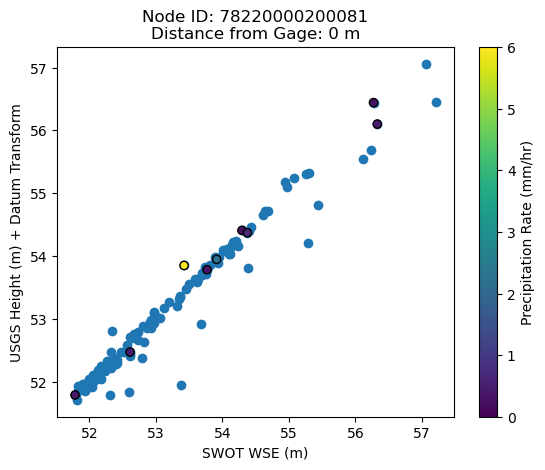

In [40]:
for node_id in combined['node_id'].unique():
    if node_id != int(willamette_node_id):
        continue
    
    node_data = combined_filtered[combined_filtered['node_id'] == node_id]
    # node_data = combined_merged[combined_merged['node_id'] == node_id]
    # node_data = albany_data[albany_data['node_id'] == node_id]
    # Color by PrecipRate_00.00
    plt.scatter(node_data['wse'], node_data['usgs_height_m_datum'])
    # Plot points with precip on top, limiting colorbar to 0-6
    plt.scatter(node_data[node_data['PrecipRate_00.00']>0]['wse'], node_data[node_data['PrecipRate_00.00']>0]['usgs_height_m_datum'],
                c=node_data[node_data['PrecipRate_00.00']>0]['PrecipRate_00.00'], cmap='viridis', edgecolor='k', vmin=0, vmax=6)
    # plt.xlim(50,60)
    # plt.ylim(50,60)
    # Add colorbar
    cbar = plt.colorbar()
    cbar.set_label('Precipitation Rate (mm/hr)')
    plt.xlabel('SWOT WSE (m)')
    plt.ylabel('USGS Height (m) + Datum Transform')
    plt.title(f'Node ID: {node_id}\nDistance from Gage: {node_data["dist_from_gage"].iloc[0]:.0f} m')
    plt.show()

In [25]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

mu_alpha_prior=albany_data['usgs_height_m_datum'].median()

# --- Create clean integer node index ---
data_for_hierarchical_model = combined_filtered.copy()
node_ids = data_for_hierarchical_model['node_id'].unique()
node_id_to_idx = {nid: i for i, nid in enumerate(sorted(node_ids))}
data_for_hierarchical_model['node_idx'] = data_for_hierarchical_model['node_id'].map(node_id_to_idx)
N_nodes = len(node_ids)

# --- Build node-level distance array ---
# One distance value per node, ordered by node_idx
# node_meta = (df.groupby('node_idx')['dist_from_gage']
#                .first()
#                .sort_index())
# dist_raw = node_meta.values  # meters

# --- Normalize inputs ---
# Gage: zero mean, unit variance
# gage_mean = df['usgs_height_m_datum'].mean()
# gage_std  = df['usgs_height_m_datum'].std()
# df['gage_norm'] = (df['usgs_height_m_datum'] - gage_mean) / gage_std

# SWOT WSE: zero mean, unit variance
# wse_mean = df['wse'].mean()
# wse_std  = df['wse'].std()
# df['wse_norm'] = (df['wse'] - wse_mean) / wse_std

# Distance: 0 to 1
# dist_norm = dist_raw / dist_raw.max()

# --- Extract arrays for PyMC ---
obs_wse   = data_for_hierarchical_model['wse'].values         # shape: (N_obs,)
gage_vals = data_for_hierarchical_model['usgs_height_m_datum'].values        # shape: (N_obs,)
node_idx  = data_for_hierarchical_model['node_idx'].values.astype(int)  # shape: (N_obs,)

print(f"N_nodes: {N_nodes}")
print(f"N_obs total: {len(data_for_hierarchical_model)}")
# print(f"dist_norm range: {dist_norm.min():.3f} to {dist_norm.max():.3f}")

N_nodes: 55
N_obs total: 9092


In [ ]:
# N_nodes = combined_filtered['node_id'].nunique()

with pm.Model() as hierarchical_wse_simple:

    # Define hyperpriors (typical alpha and beta across all nodes on this reach)
    mu_alpha = pm.Normal('mu_alpha', mu=mu_alpha_prior, sigma=1.0)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1.0)

    mu_beta = pm.Normal('mu_beta', mu=1, sigma=0.5)
    sigma_beta = pm.HalfNormal('sigma_beta', sigma=0.5)


    # node-specific parameters
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=len(node_ids))
    beta = pm.Normal('beta', mu=mu_beta, sigma=sigma_beta, shape=len(node_ids))

    # Likelihood
    wse_predicted = alpha[node_idx] + beta[node_idx] * gage_vals
    sigma = pm.HalfNormal('sigma', sigma=1.0)

    pm.Normal('wse_obs', mu=wse_predicted, sigma=sigma, observed=obs_wse)

In [27]:
with hierarchical_wse_simple:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        nuts_sampler='nutpie'
    )
    # varying_intercept_trace = pm.sample(tune=2000)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.05,511
,3000,0,0.05,1023
,3000,0,0.05,511
,3000,0,0.05,511


In [28]:
az.summary(trace, var_names=['mu_alpha', 'sigma_alpha', 'mu_beta', 'sigma_beta', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,44.511,1.007,42.666,46.436,0.011,0.012,8329.0,6385.0,1.0
sigma_alpha,15.840,0.537,14.846,16.860,0.006,0.006,8444.0,5683.0,1.0
mu_beta,0.891,0.008,0.875,0.906,0.000,0.000,5064.0,5982.0,1.0
sigma_beta,0.042,0.009,0.024,0.059,0.000,0.000,1364.0,2026.0,1.0
sigma,0.661,0.005,0.652,0.671,0.000,0.000,7627.0,4869.0,1.0


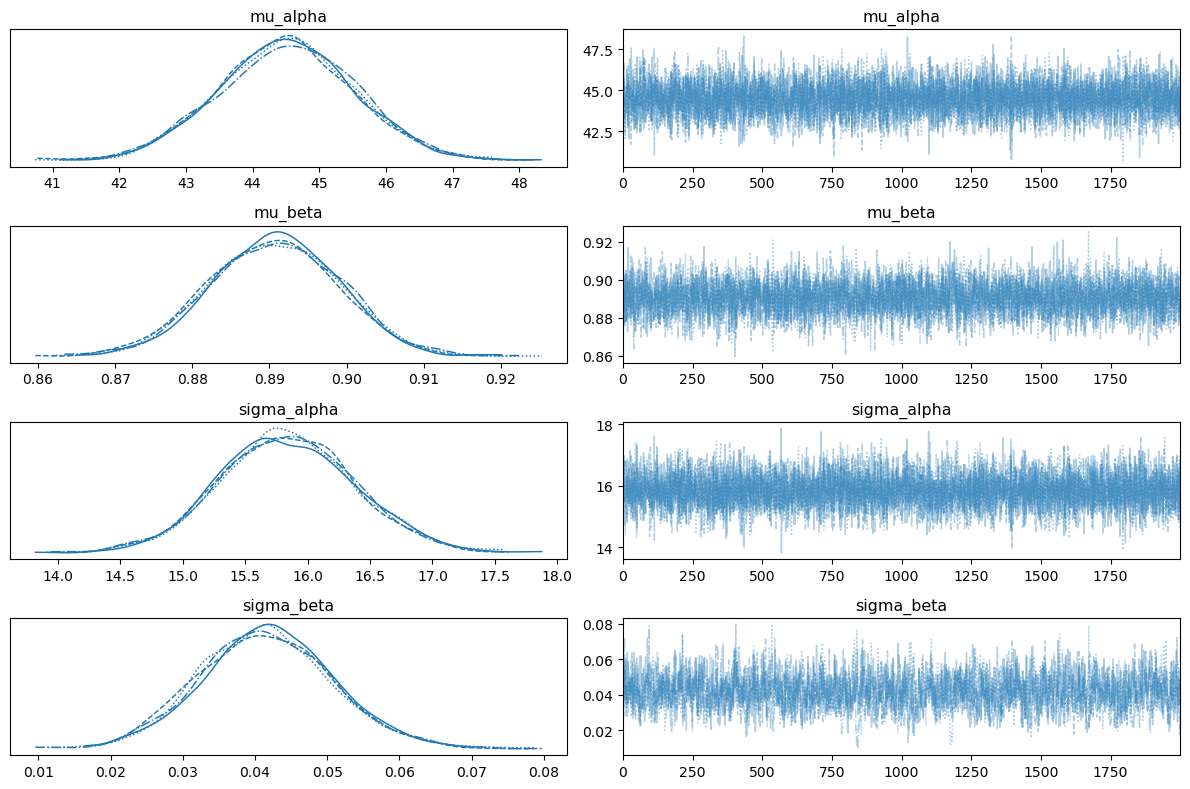

In [30]:
az.plot_trace(trace, var_names=['mu_alpha', 'mu_beta', 'sigma_alpha', 'sigma_beta'])
plt.tight_layout()

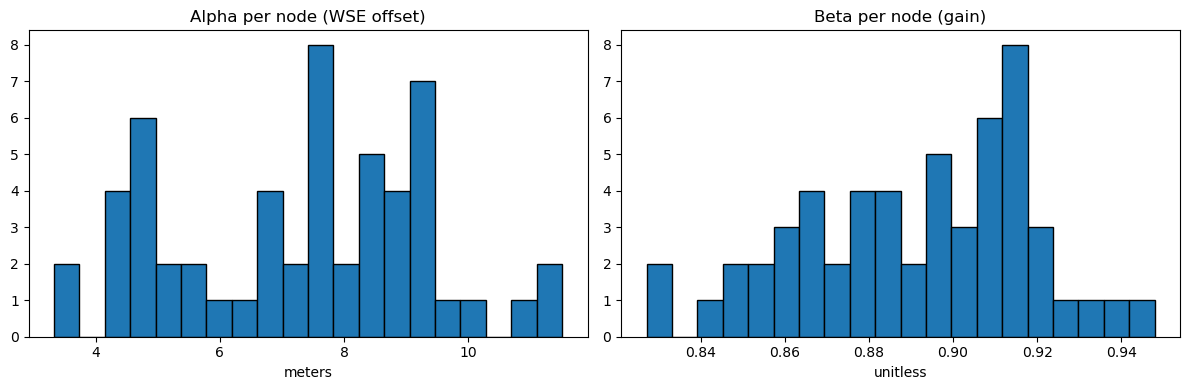

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Extract posterior means for each node
alpha_mean = trace.posterior['alpha'].mean(dim=['chain', 'draw']).values
beta_mean  = trace.posterior['beta'].mean(dim=['chain', 'draw']).values

# Plot them
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alpha_mean, bins=20, edgecolor='black')
axes[0].set_title('Alpha per node (WSE offset)')
axes[0].set_xlabel('meters')

axes[1].hist(beta_mean, bins=20, edgecolor='black')
axes[1].set_title('Beta per node (gain)')
axes[1].set_xlabel('unitless')

plt.tight_layout()

In [34]:
# Keep every 4th draw — reduces 8000 to 2000 samples
thin_trace = trace.isel(draw=slice(None, None, 5))

with hierarchical_wse_simple:
    ppc = pm.sample_posterior_predictive(thin_trace)

Sampling: [wse_obs]


Output()

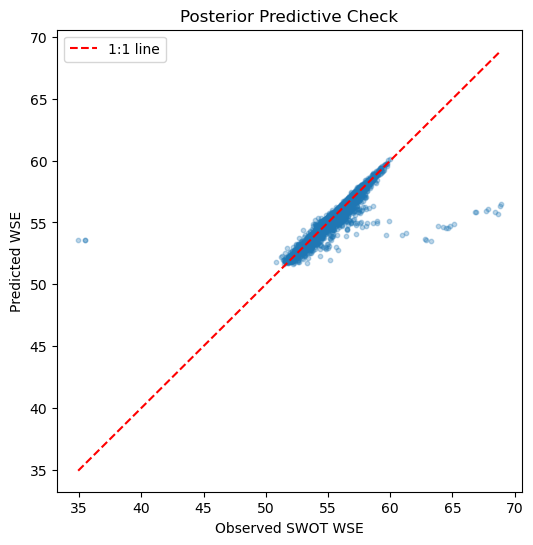

In [35]:
predicted = ppc.posterior_predictive['wse_obs'].mean(dim=['chain', 'draw']).values
observed  = obs_wse

plt.figure(figsize=(6, 6))
plt.scatter(observed, predicted, alpha=0.3, s=10)
plt.plot([observed.min(), observed.max()],
         [observed.min(), observed.max()],
         'r--', label='1:1 line')
plt.xlabel('Observed SWOT WSE')
plt.ylabel('Predicted WSE')
plt.title('Posterior Predictive Check')
plt.legend()

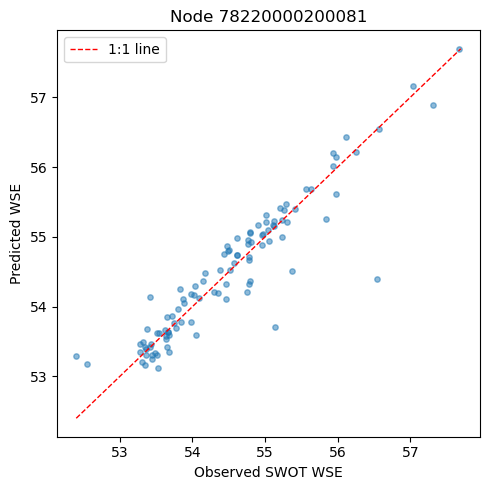

In [38]:
predicted = ppc.posterior_predictive['wse_obs'].mean(dim=['chain', 'draw']).values
unique_nodes = combined_filtered['node_id'].unique()
for i in range(N_nodes):
    mask = node_idx == i
    node = unique_nodes[i]
    if node != int(willamette_node_id):
        continue
    obs_i  = obs_wse[mask]
    pred_i = predicted[mask]
    
    lims = [min(obs_i.min(), pred_i.min()),
            max(obs_i.max(), pred_i.max())]
    
    plt.figure(figsize=(5, 5))
    plt.scatter(obs_i, pred_i, alpha=0.5, s=15)
    plt.plot(lims, lims, 'r--', linewidth=1, label='1:1 line')
    plt.xlabel('Observed SWOT WSE')
    plt.ylabel('Predicted WSE')
    plt.title(f'Node {node}')
    plt.legend()
    plt.tight_layout()
    plt.show()

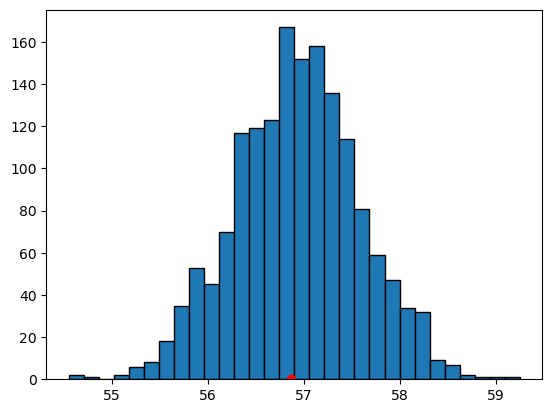

In [58]:
index=110
values = ppc.posterior_predictive.sel(wse_obs_dim_0=index)['wse_obs'].values.flatten()
plt.hist(values, bins=30, edgecolor='black')
plt.plot(obs_wse[index], 0, 'ro')  # Plot the observed value as a red dot

In [61]:
combined_filtered

,node_id,time_str,wse,width,area_total,node_q_b,ice_clim_f,xovr_cal_q,p_dam_id,node_q,...,qualifier,last_modified,continuous_id,usgs_height_m,mrms_time,PrecipRate_00.00,dist_out,dist_from_gage,usgs_height_m_datum,index
0,78220000200531,2023-04-02 08:16:16+00:00,56.58625,185.028126,39546.9,0,0,0,0,0,...,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,2023-04-02 08:16:00+00:00,0.0,366750.326612,9026.810277,53.631484,0
1,78220000200521,2023-04-02 08:16:16+00:00,56.52450,134.484034,25257.8,0,0,0,0,0,...,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,2023-04-02 08:16:00+00:00,0.0,366536.592043,8813.075707,53.631484,1
2,78220000200541,2023-04-02 08:16:16+00:00,56.51212,277.890669,54638.5,9,0,0,0,1,...,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,2023-04-02 08:16:00+00:00,0.0,366946.945384,9223.429048,53.631484,2
3,78220000200551,2023-04-02 08:16:16+00:00,56.88189,132.378820,28708.5,4,0,0,0,1,...,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,2023-04-02 08:16:00+00:00,0.0,367163.811866,9440.295531,53.631484,3
4,78220000200501,2023-04-02 08:16:16+00:00,57.10864,141.824886,30216.5,0,0,0,0,0,...,None,2025-09-02 12:05:01.445830+00:00,cb2d21a5-3152-4144-b2bf-9cf706f3311c,2.694432,2023-04-02 08:16:00+00:00,0.0,366164.612615,8441.096279,53.631484,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11505,78220000200051,2026-01-25 15:51:03+00:00,51.90816,84.598962,19077.7,2052,0,0,0,1,...,None,2026-01-25 15:57:21.051930+00:00,02cd9984-1a53-4384-82d4-d025c63eec18,1.322832,2026-01-25 15:50:00+00:00,0.0,357136.379967,-587.136369,52.259884,9087
11506,78220000200121,2026-01-25 15:51:03+00:00,52.77455,64.498154,13626.7,0,0,0,0,0,...,None,2026-01-25 15:57:21.051930+00:00,02cd9984-1a53-4384-82d4-d025c63eec18,1.322832,2026-01-25 15:50:00+00:00,0.0,358541.280903,817.764568,52.259884,9088
11507,78220000200301,2026-01-25 15:51:03+00:00,53.82244,64.354669,15791.3,0,0,0,0,0,...,None,2026-01-25 15:57:21.051930+00:00,02cd9984-1a53-4384-82d4-d025c63eec18,1.322832,2026-01-25 15:50:00+00:00,0.0,362169.814547,4446.298211,52.259884,9089
11509,78220000200401,2026-01-25 15:51:03+00:00,55.35101,39.234172,7383.7,2052,0,0,0,1,...,None,2026-01-25 15:57:21.051930+00:00,02cd9984-1a53-4384-82d4-d025c63eec18,1.322832,2026-01-25 15:50:00+00:00,0.0,364165.739689,6442.223353,52.259884,9090


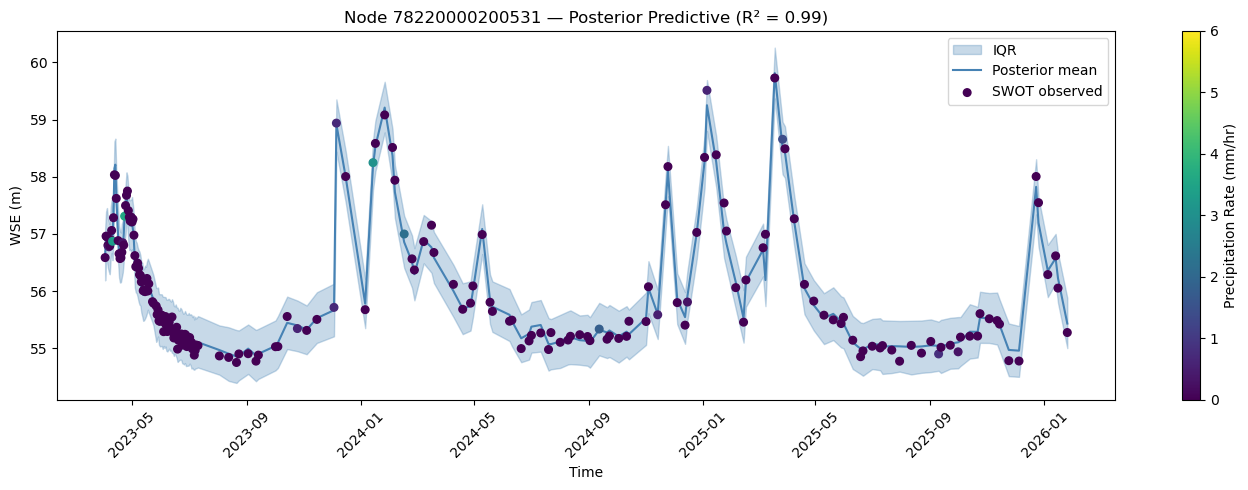

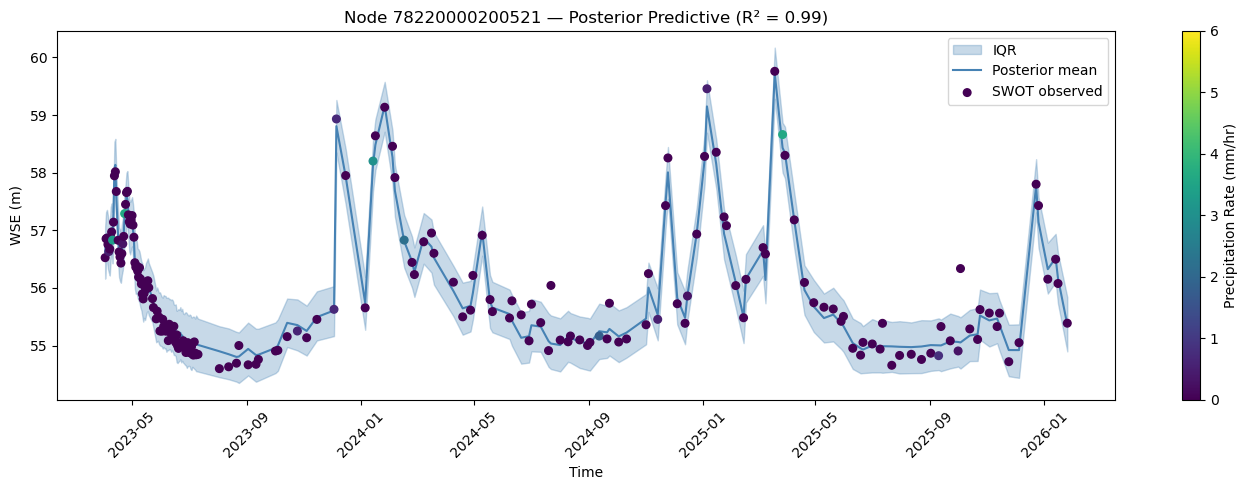

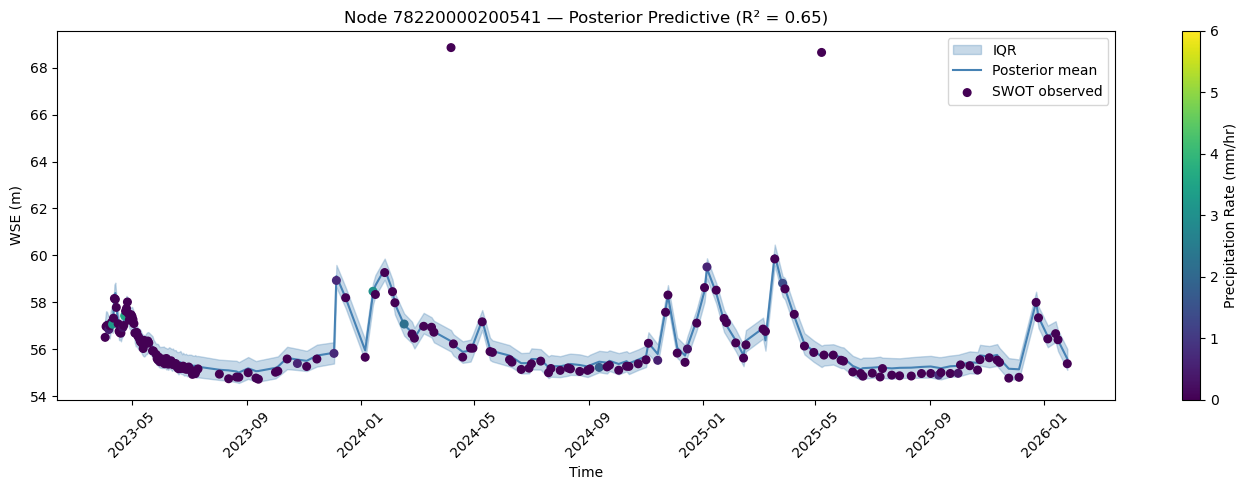

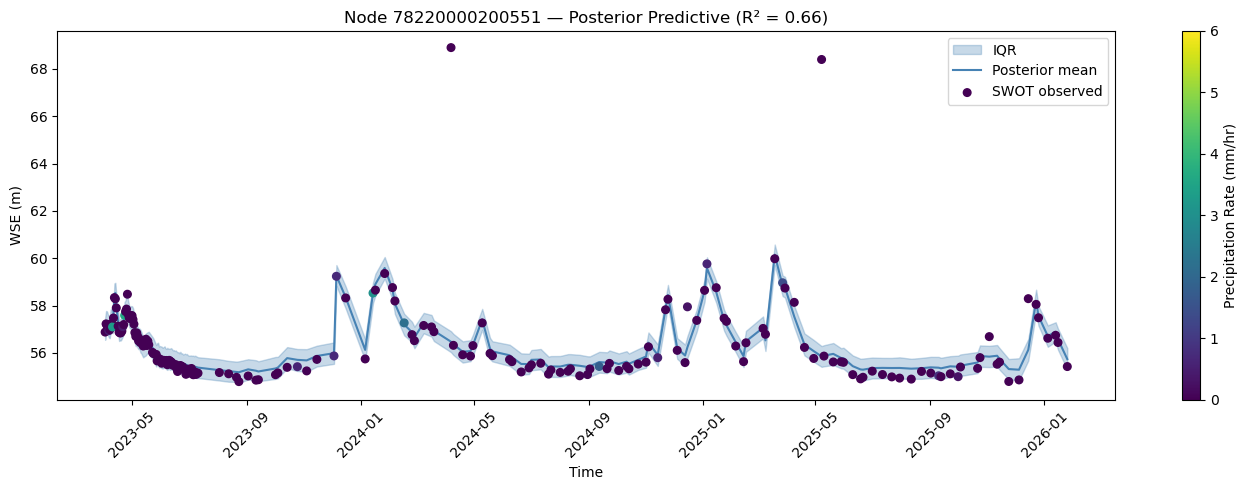

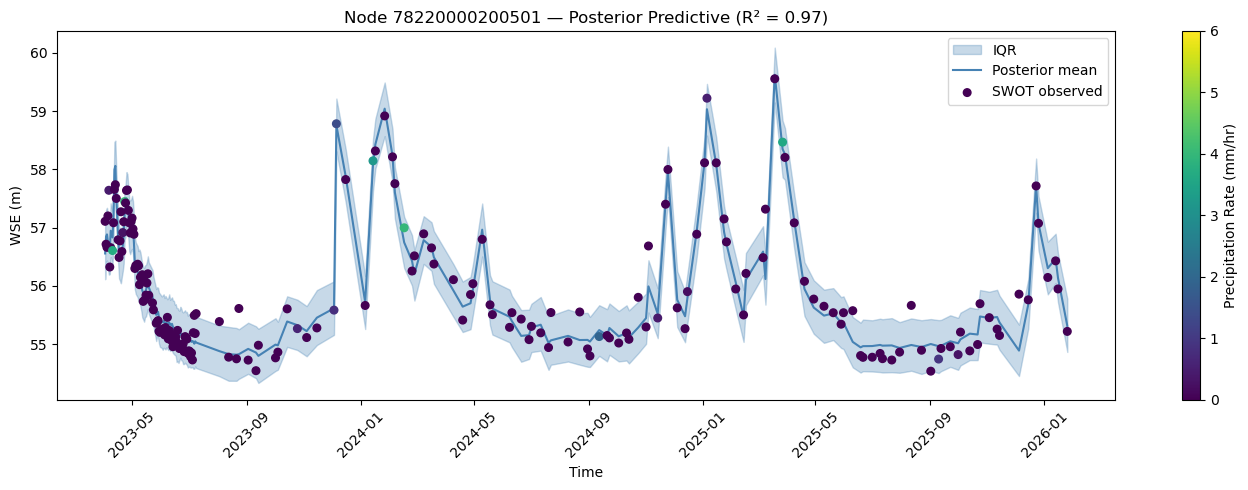

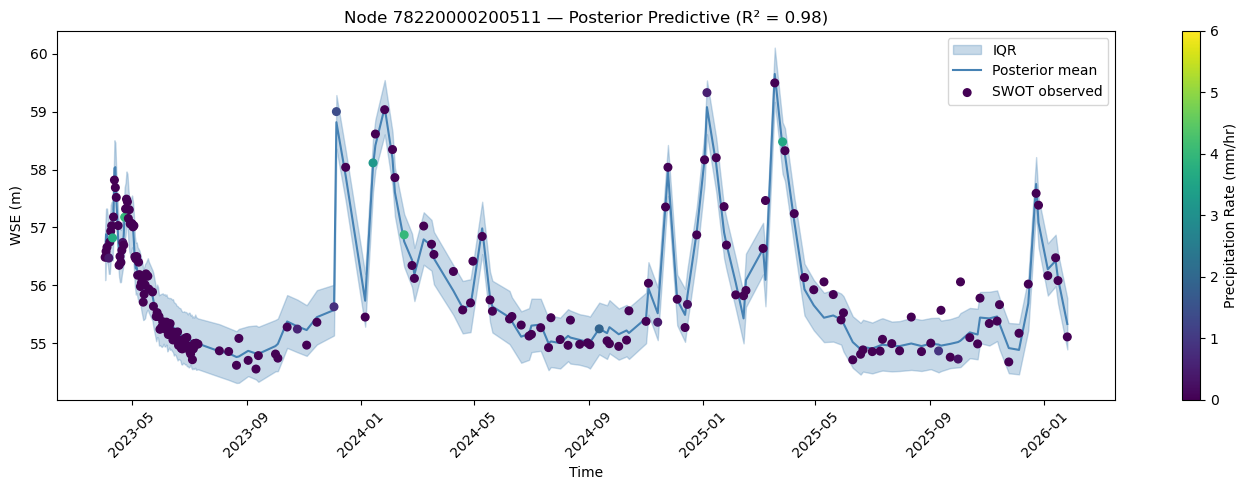

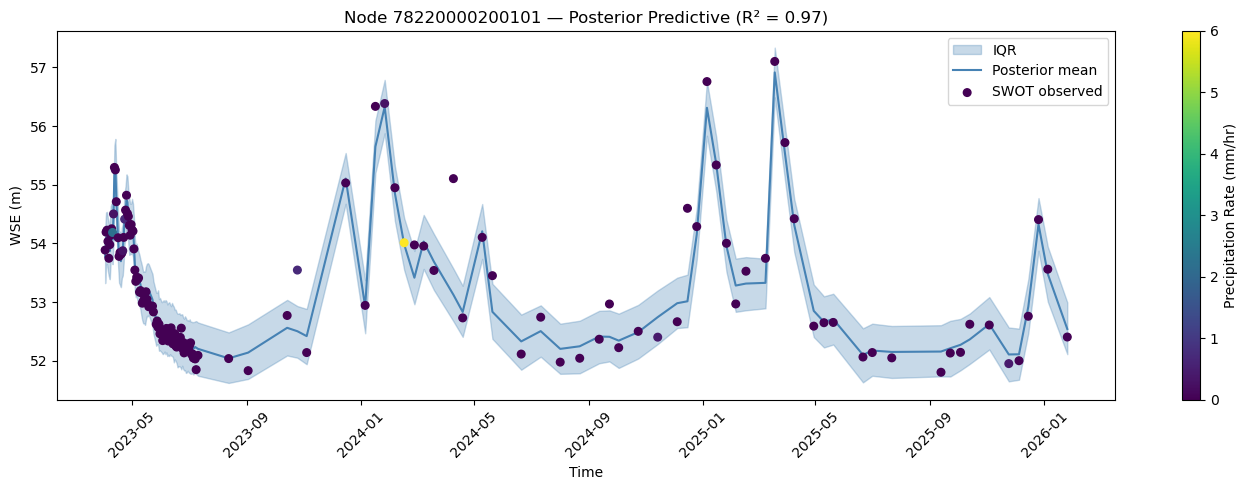

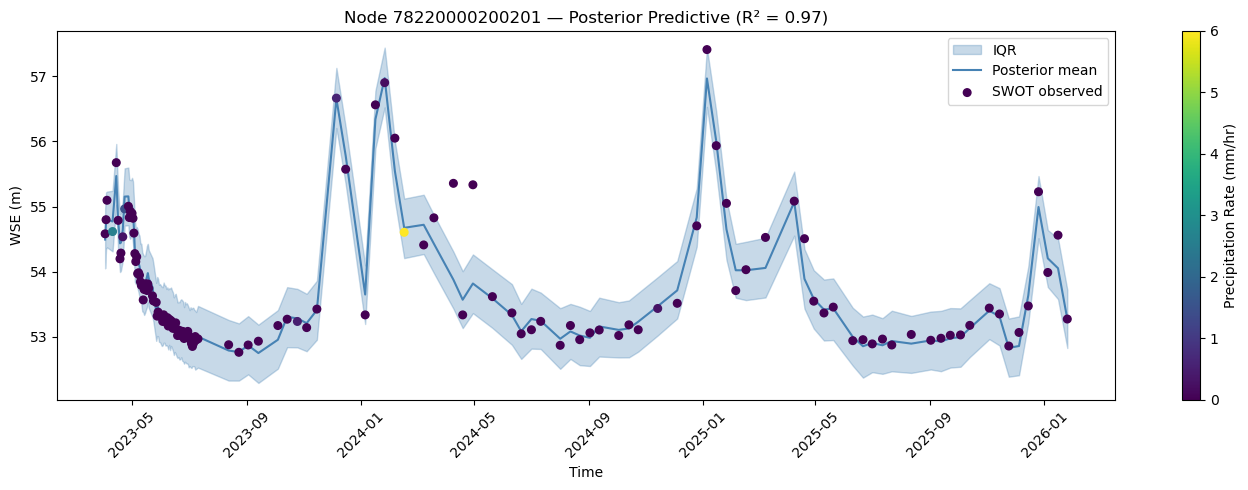

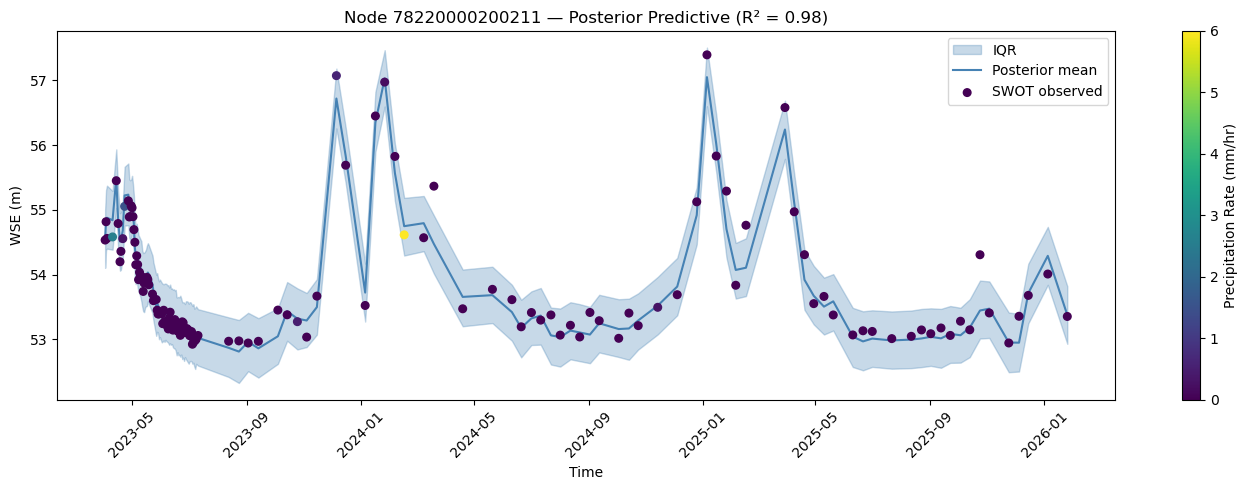

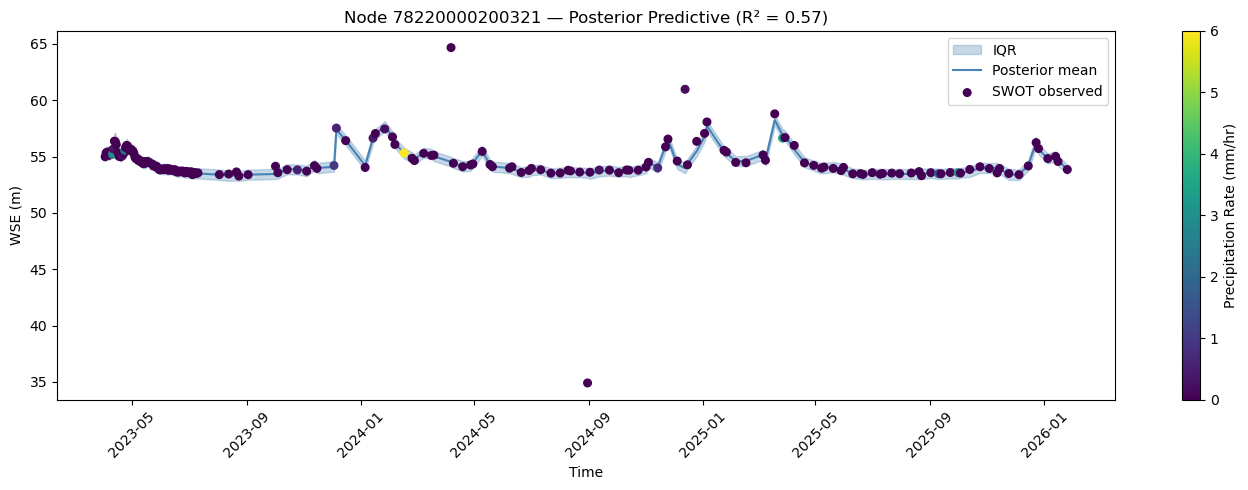

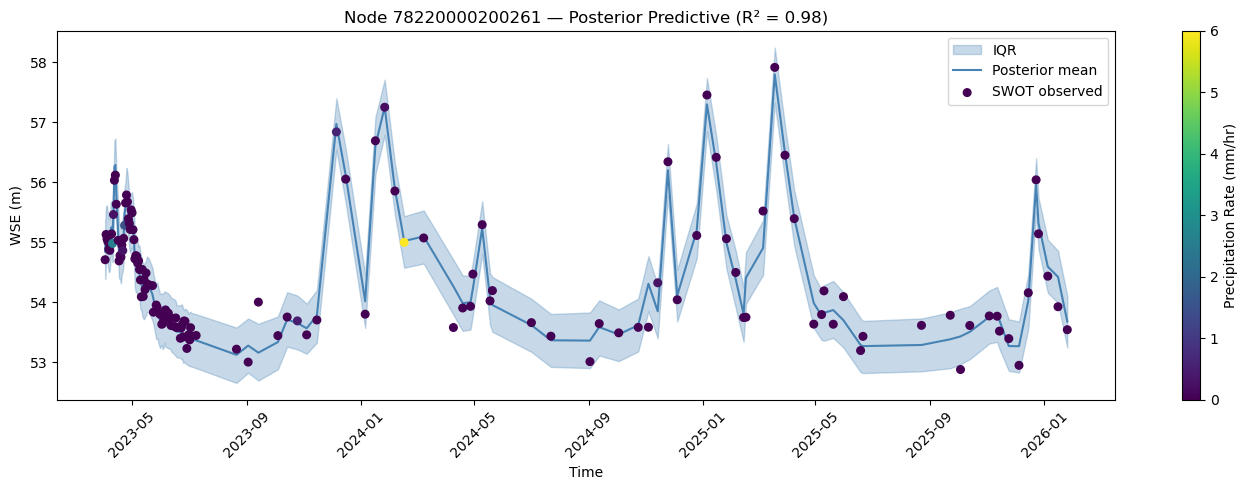

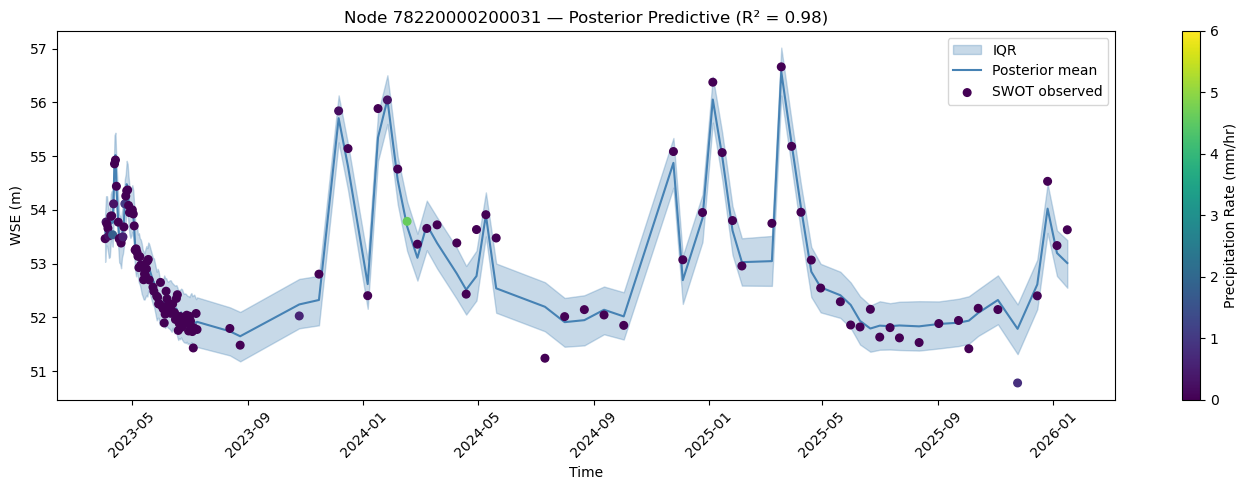

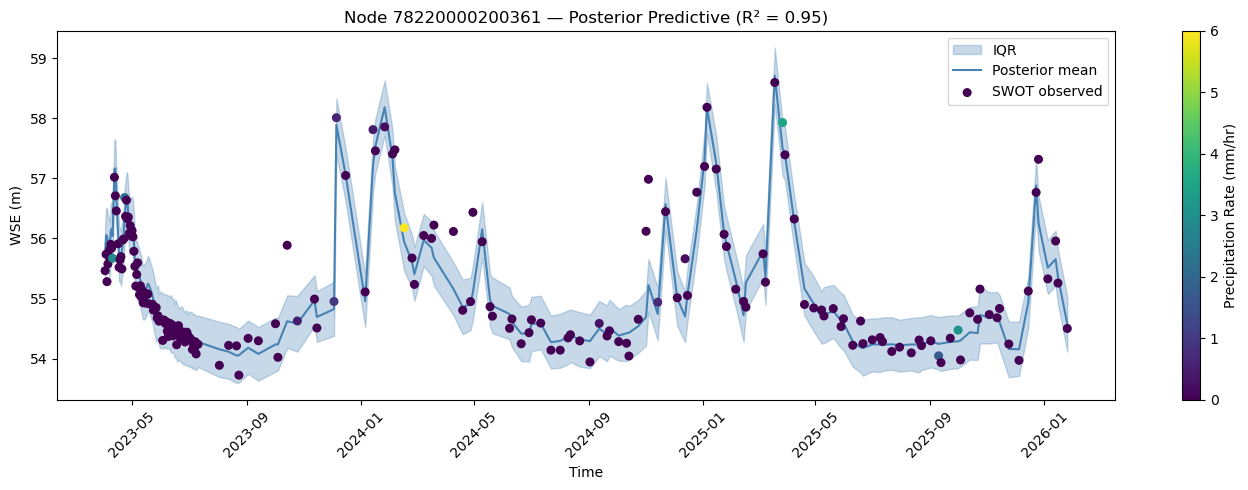

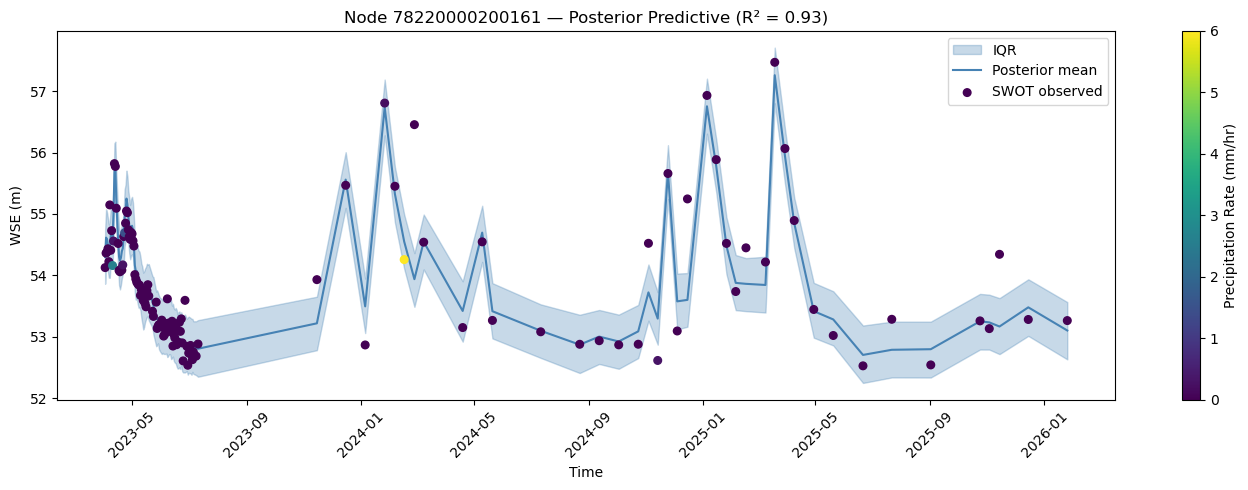

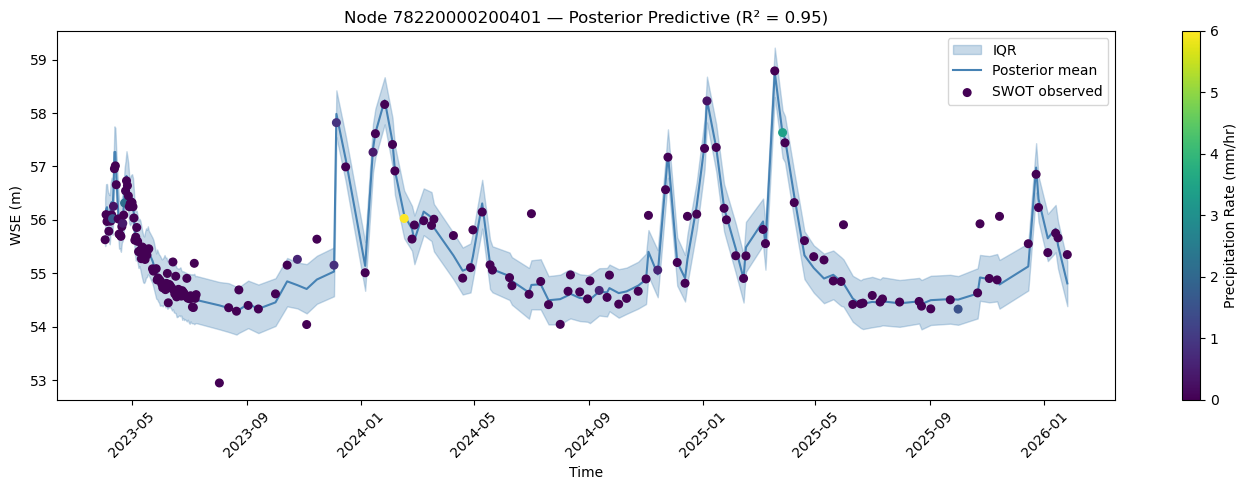

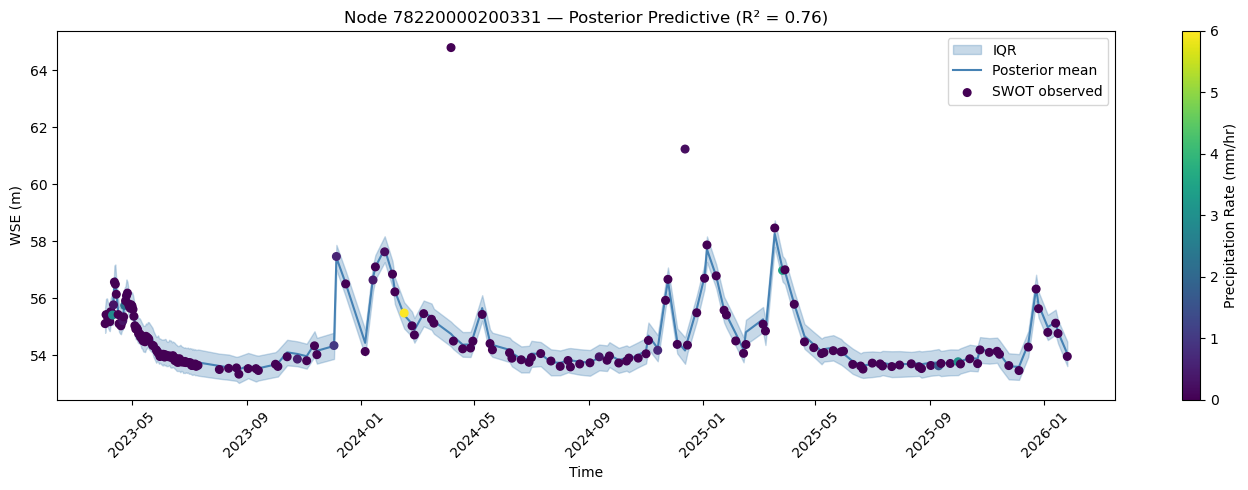

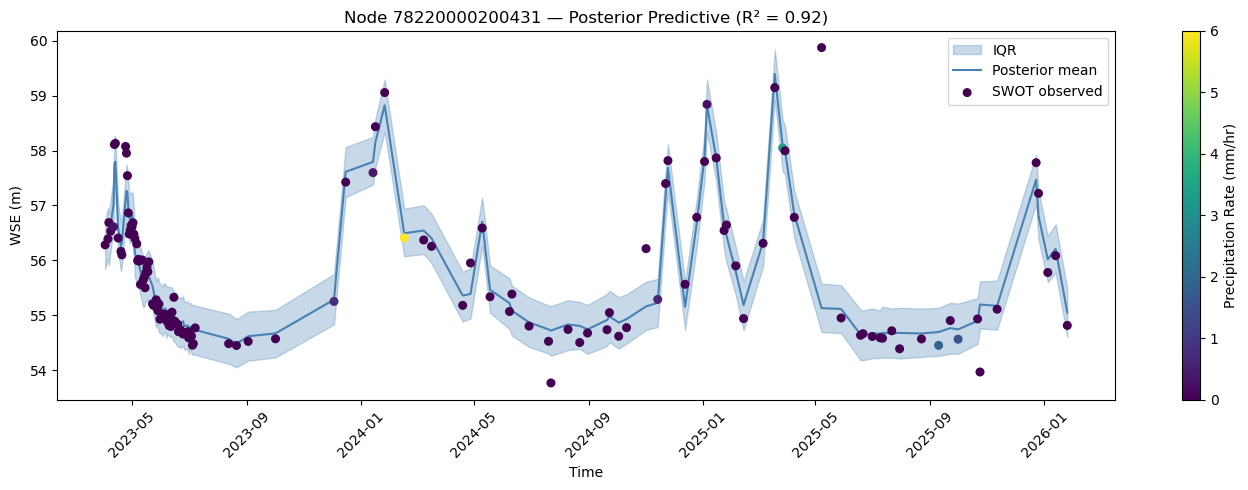

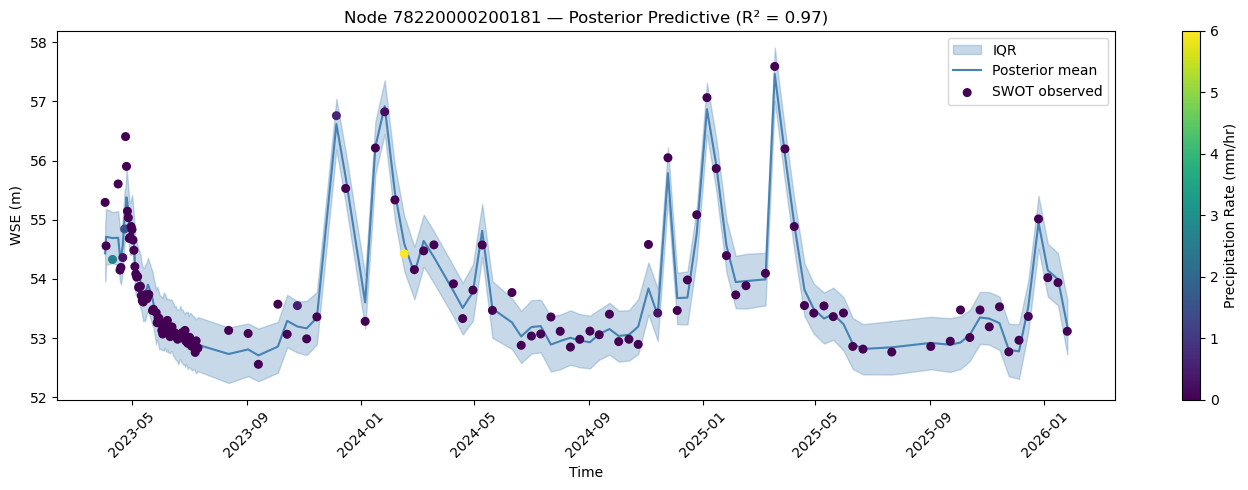

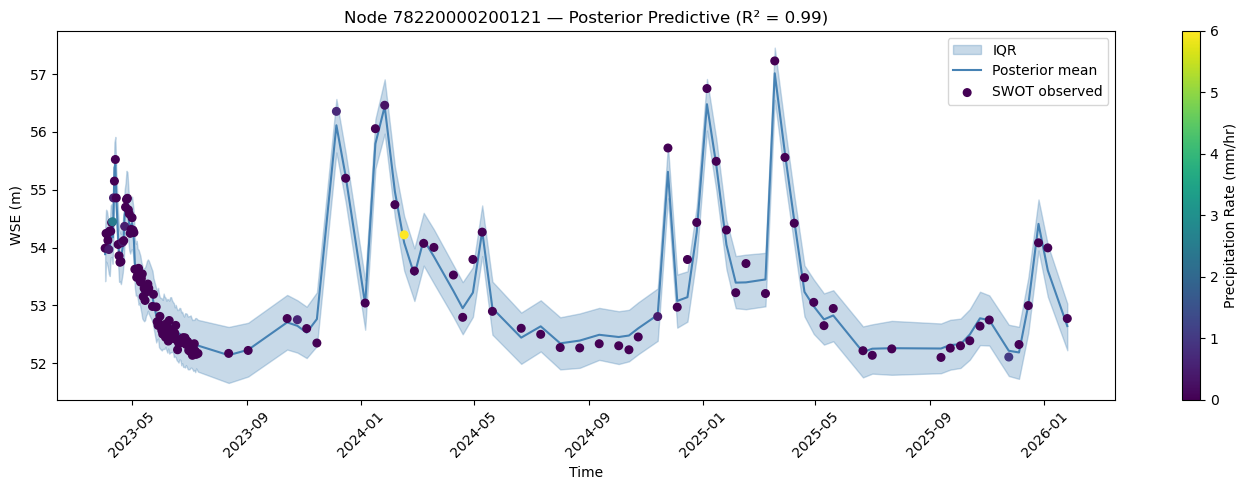

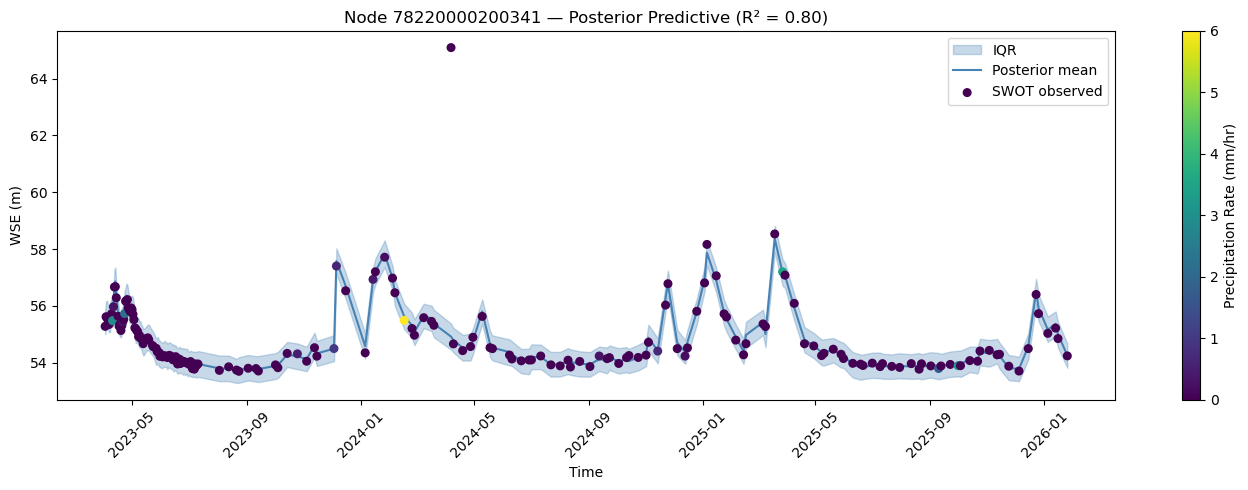

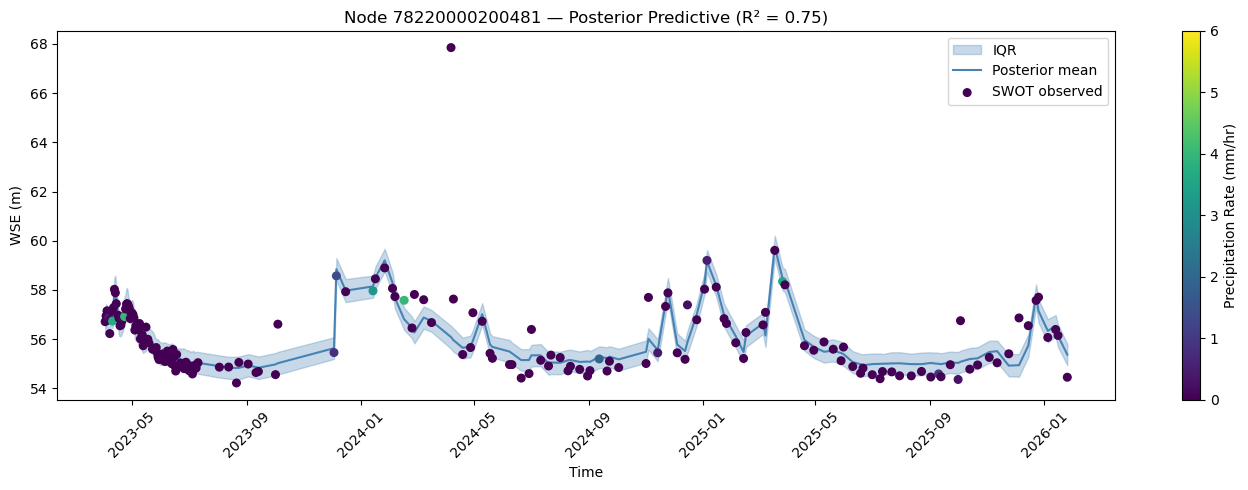

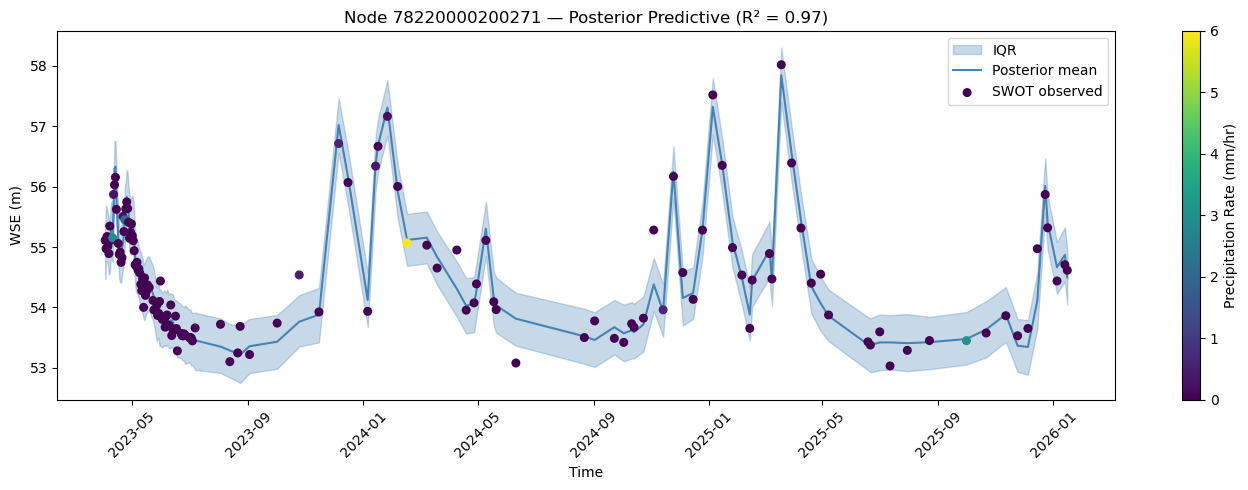

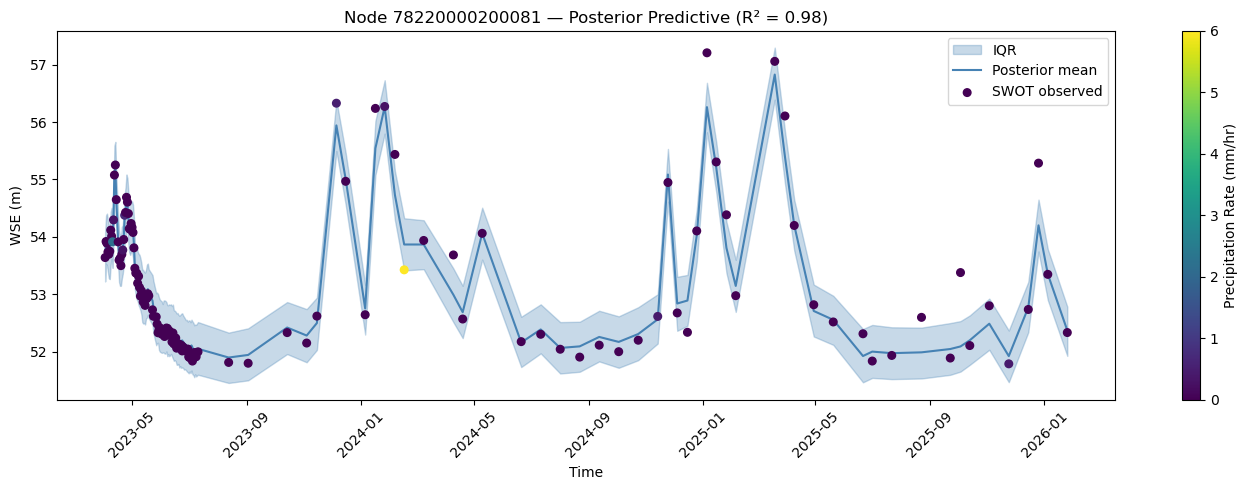

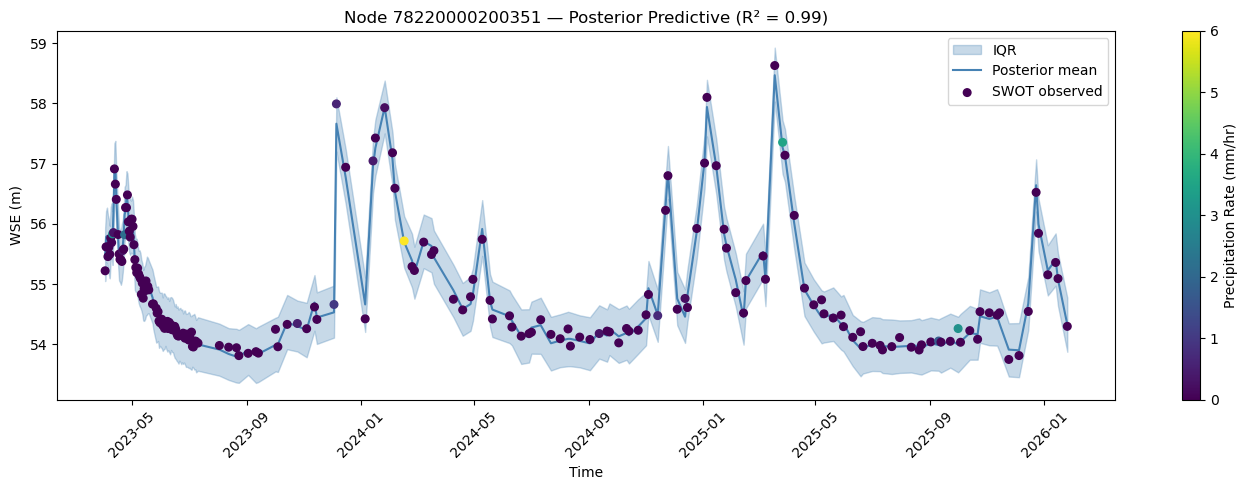

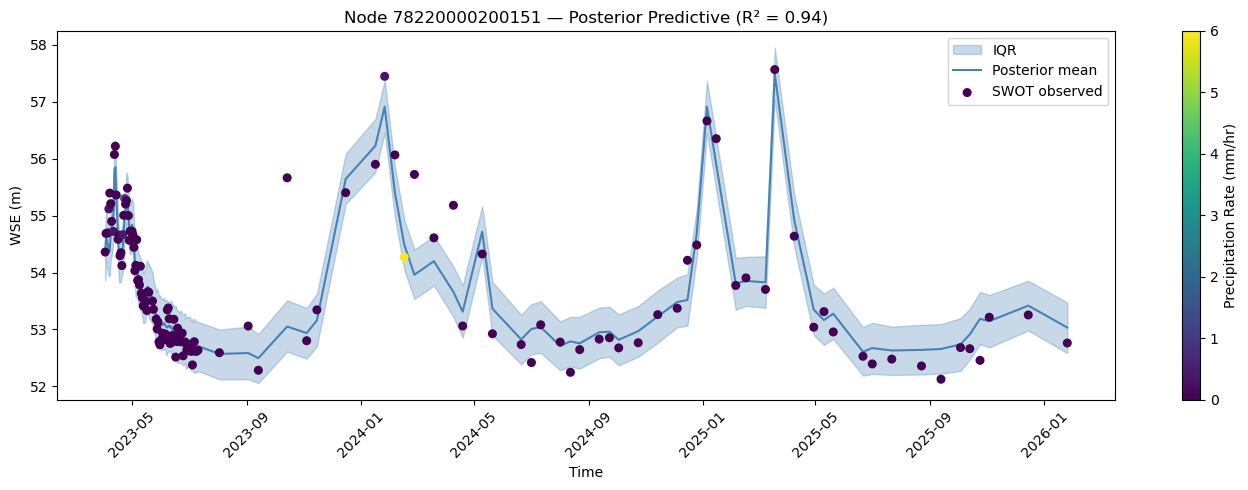

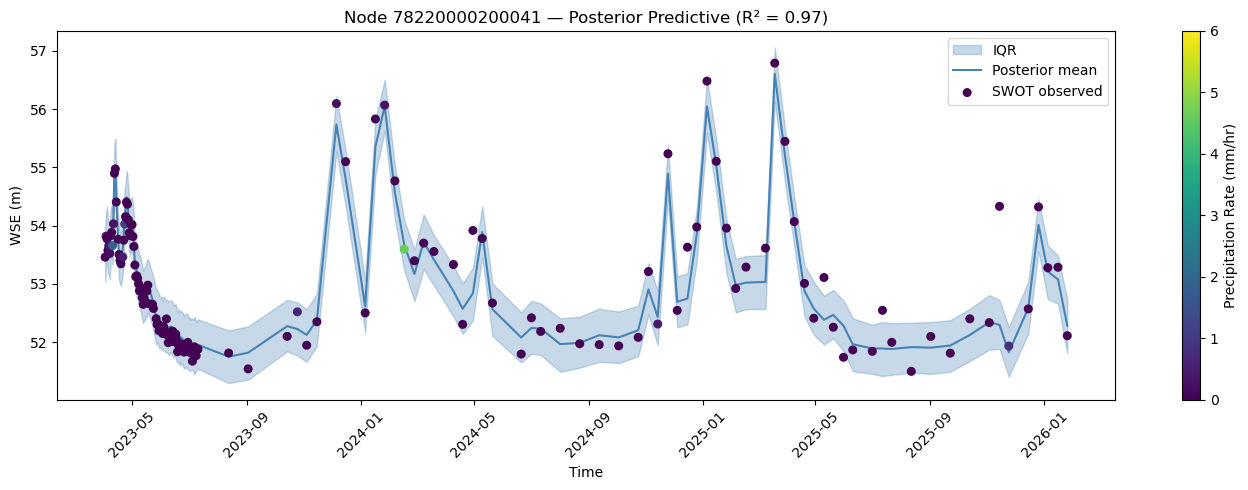

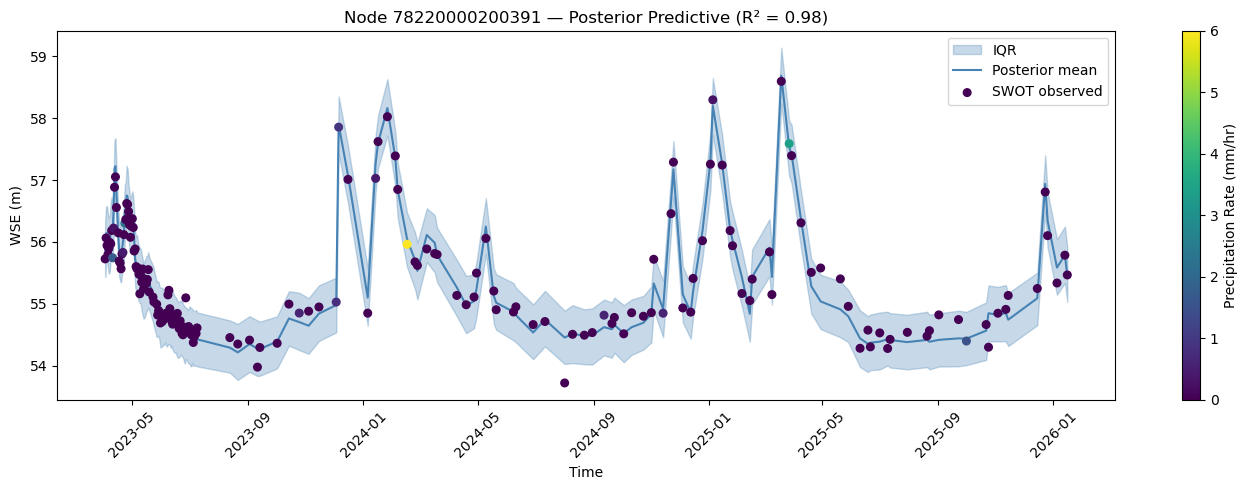

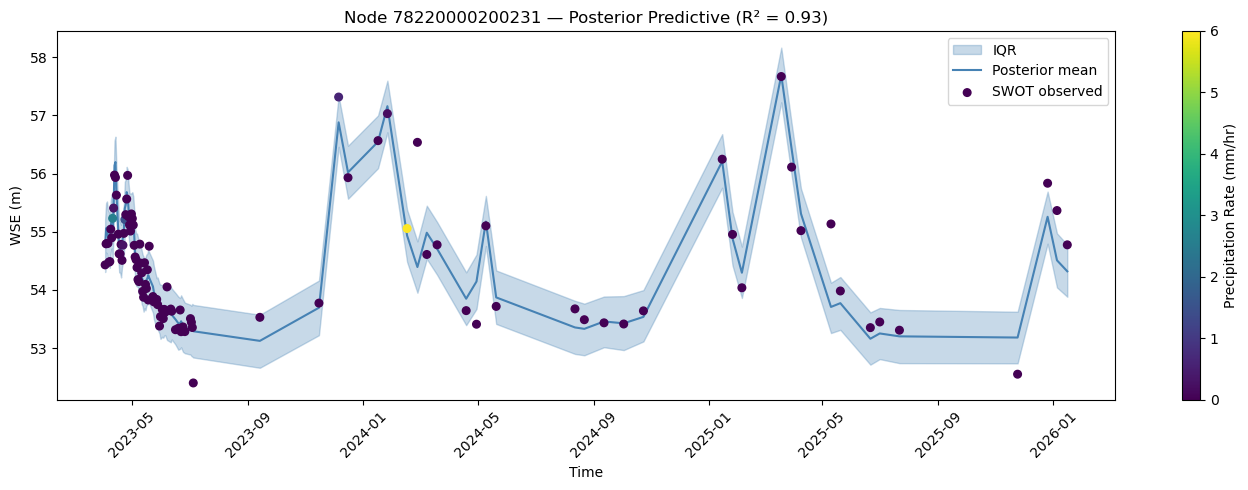

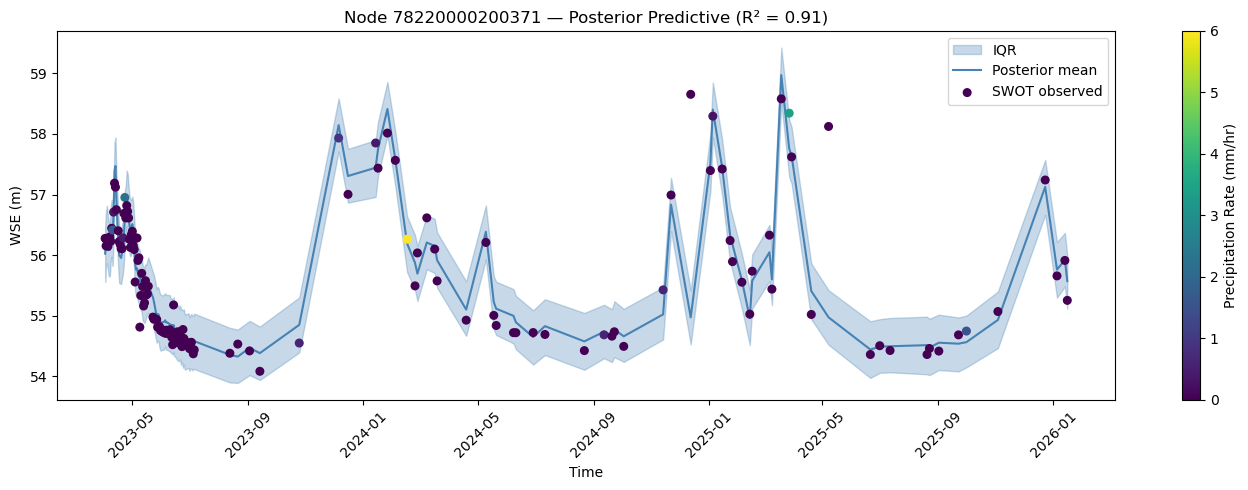

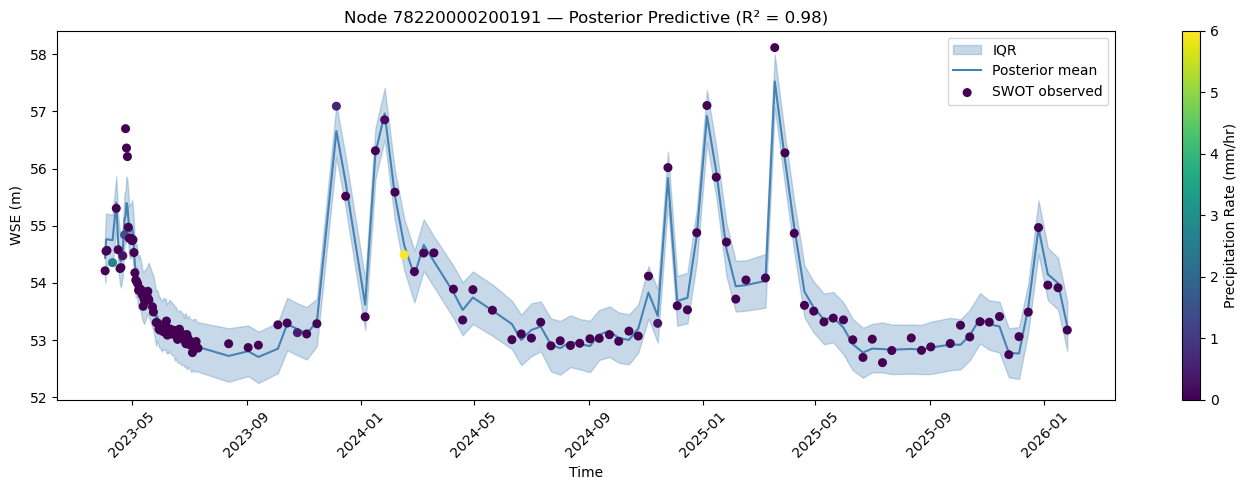

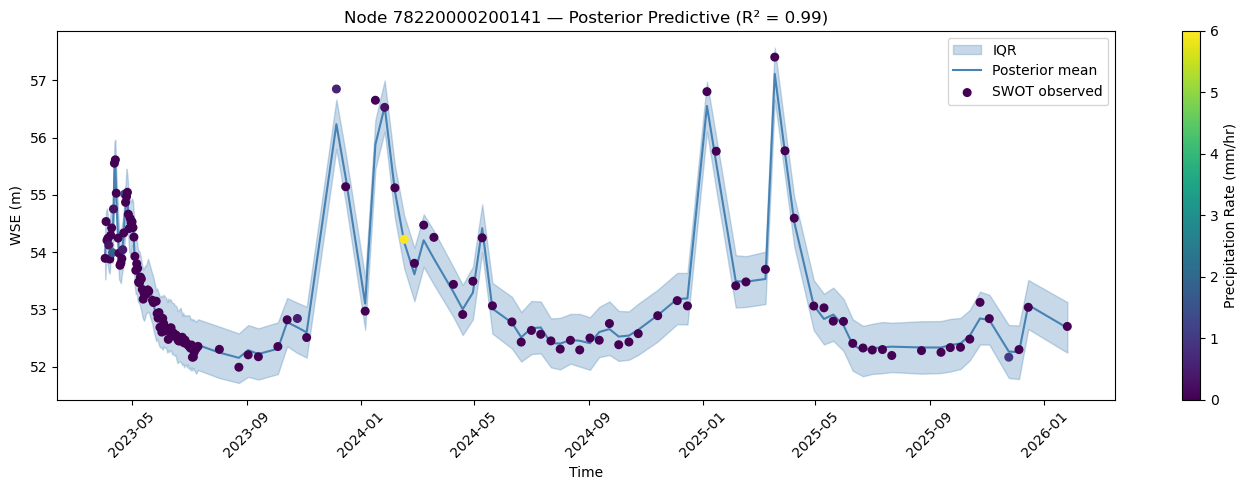

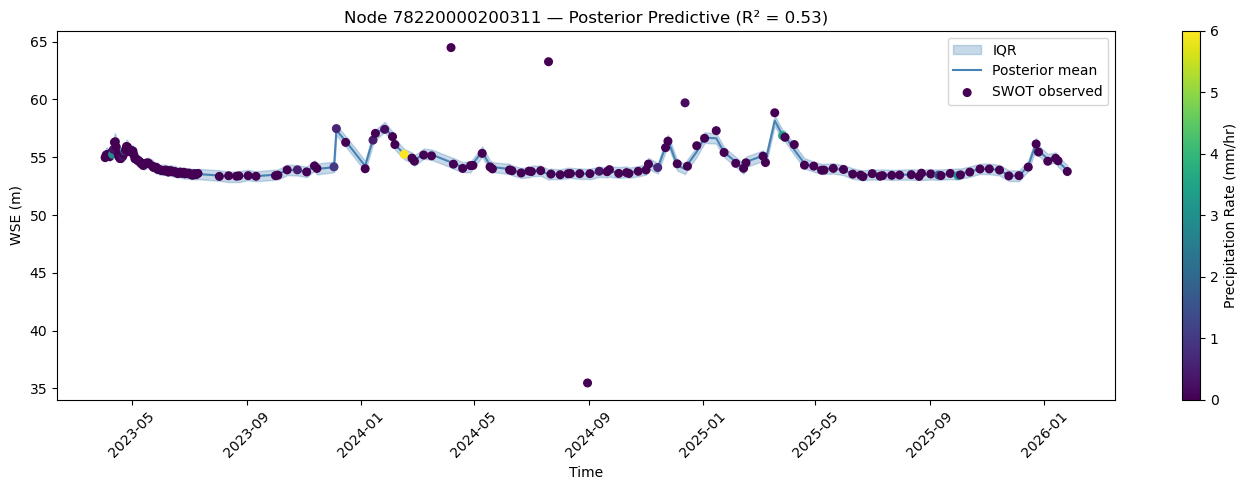

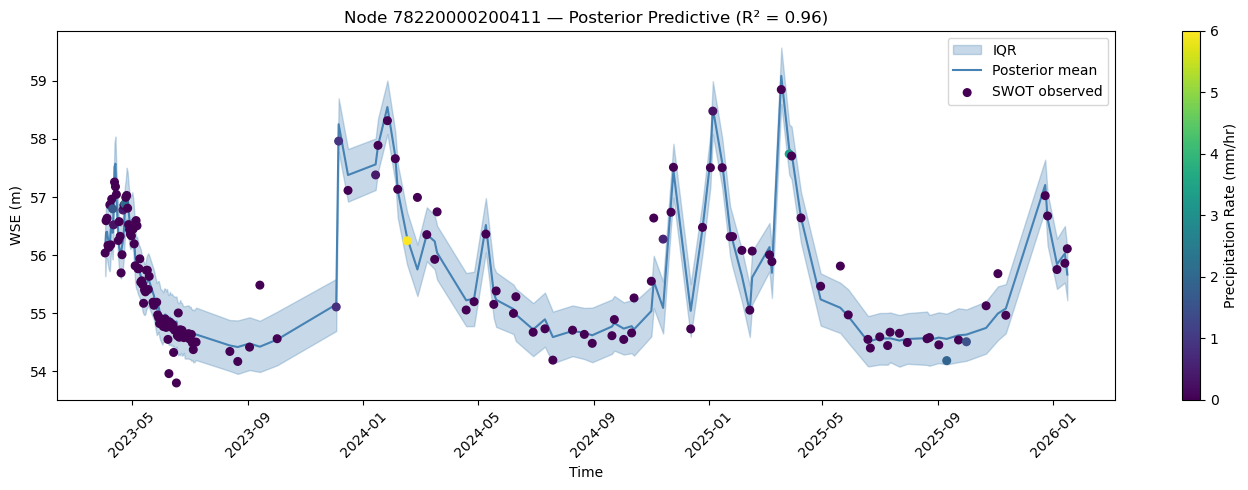

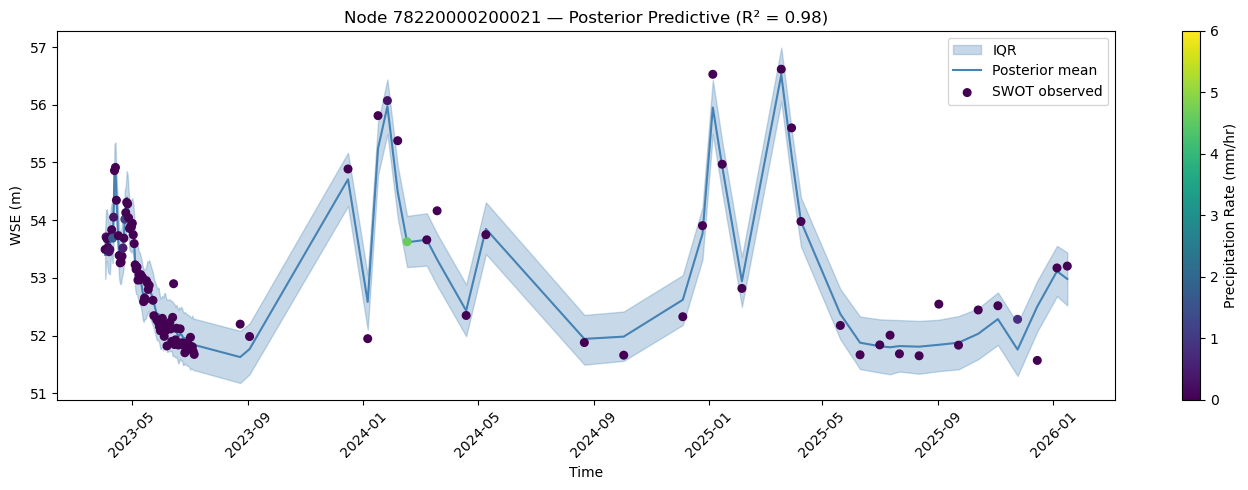

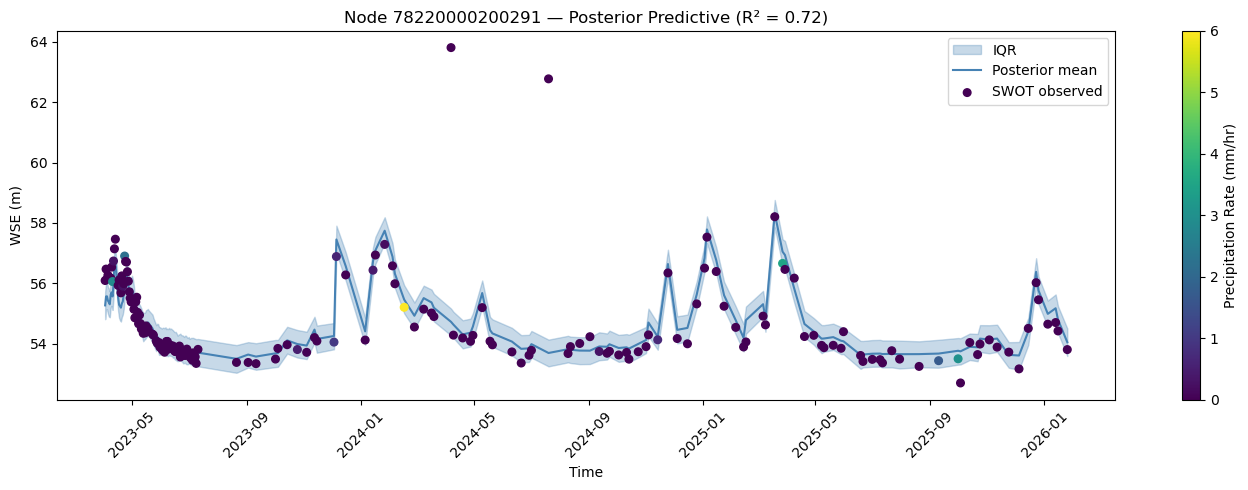

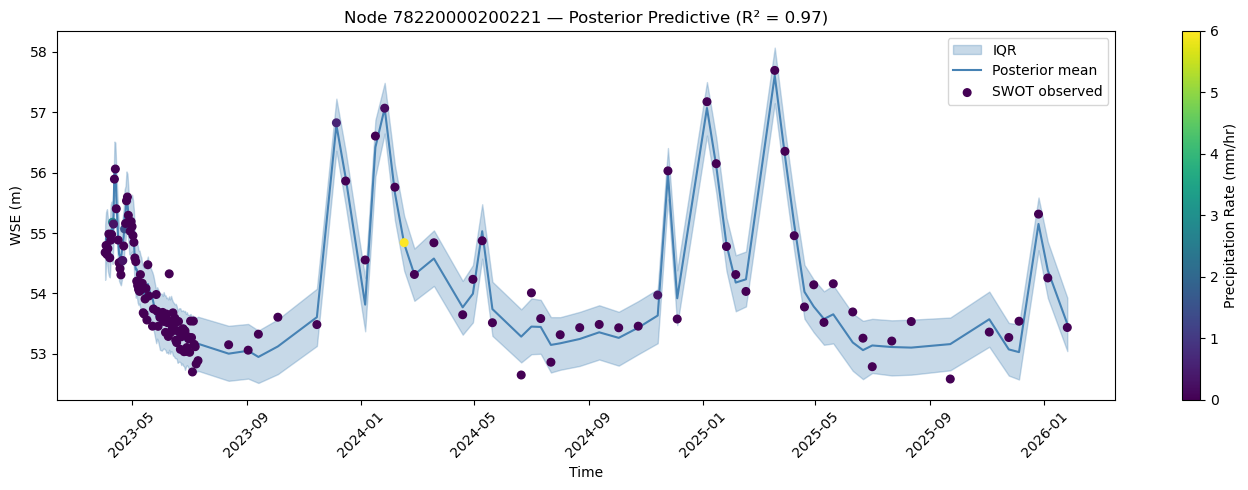

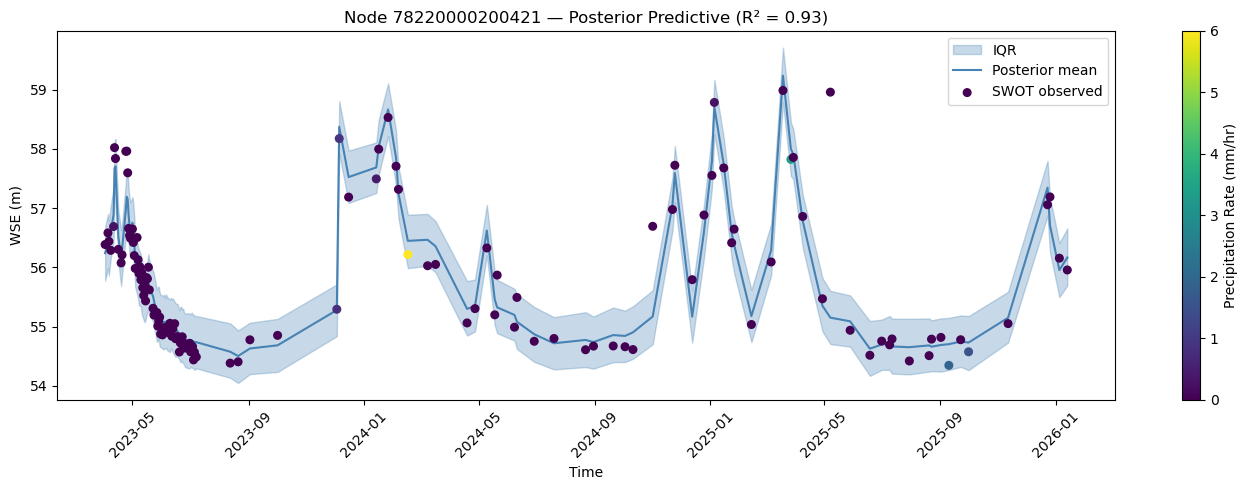

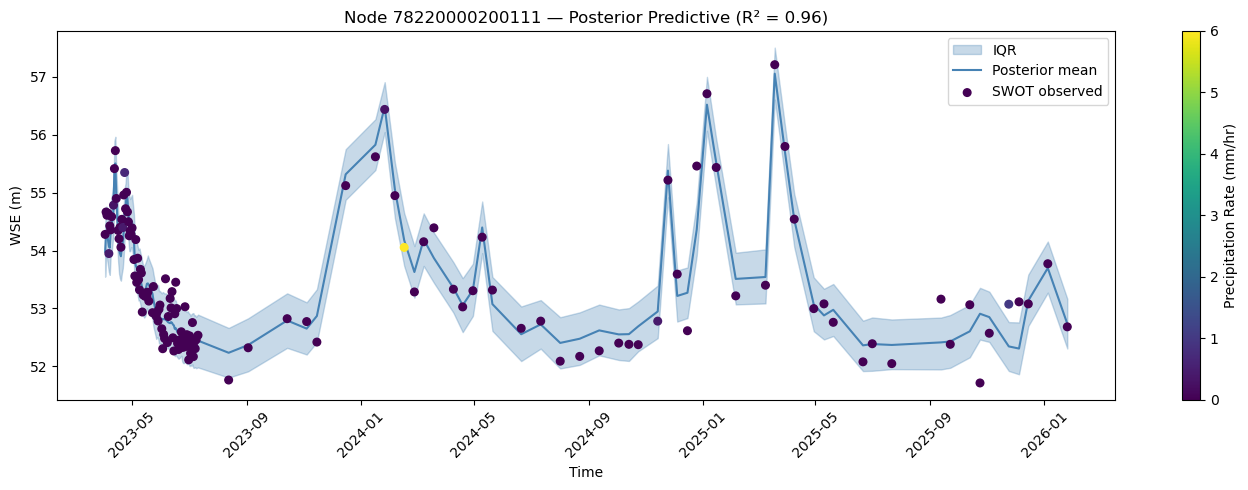

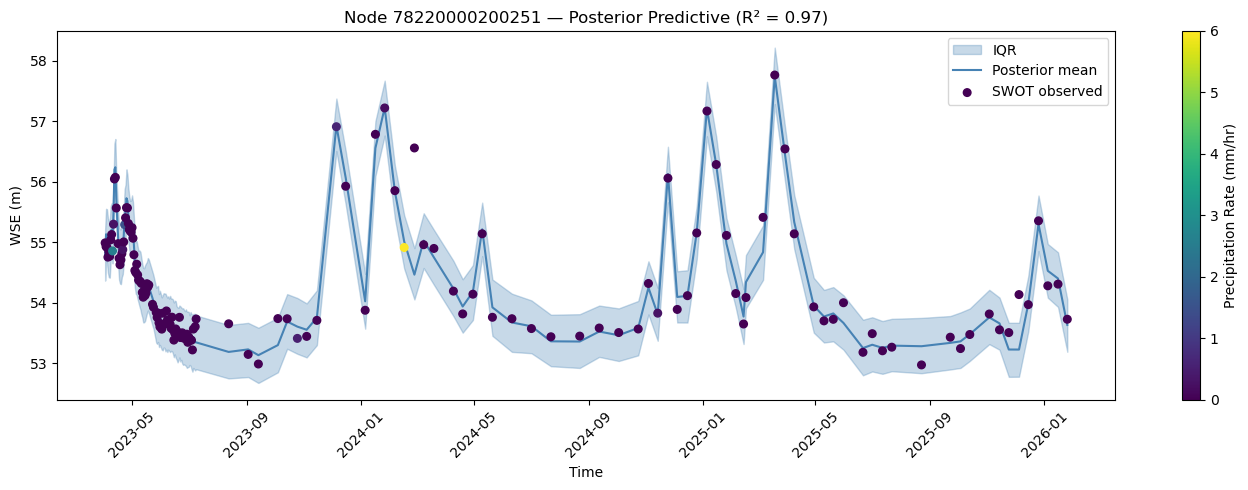

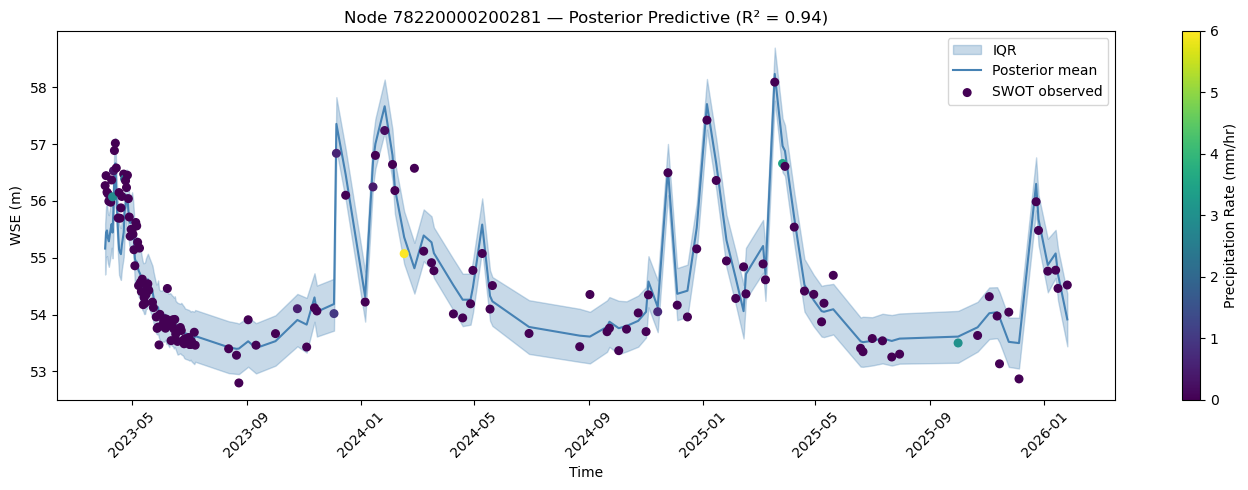

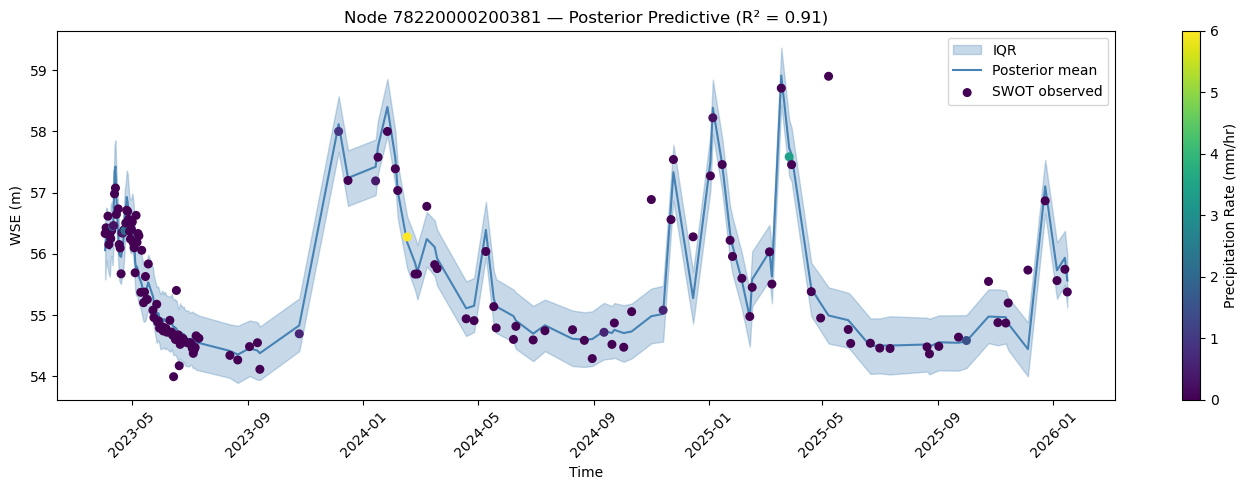

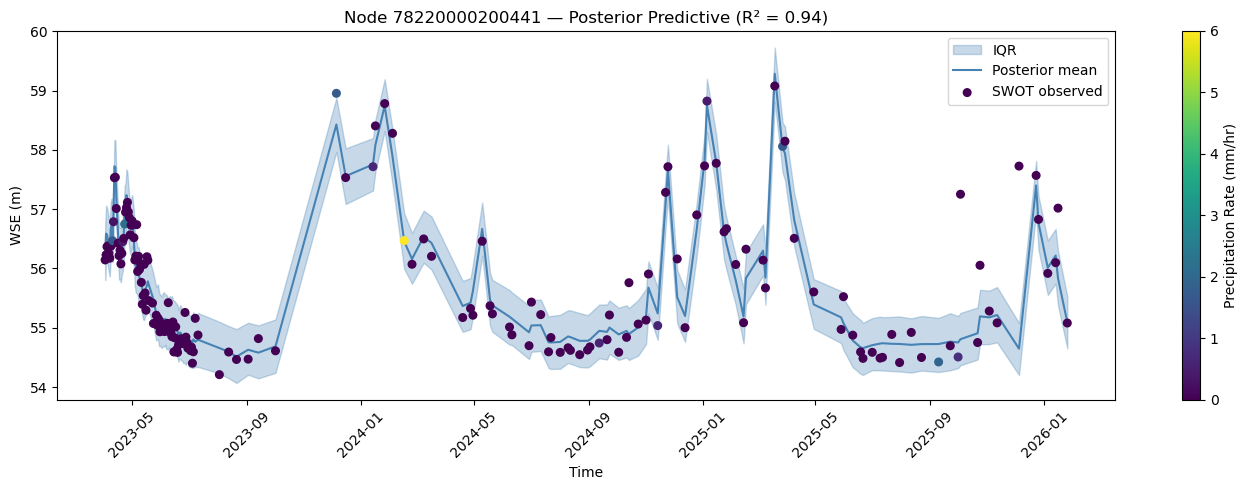

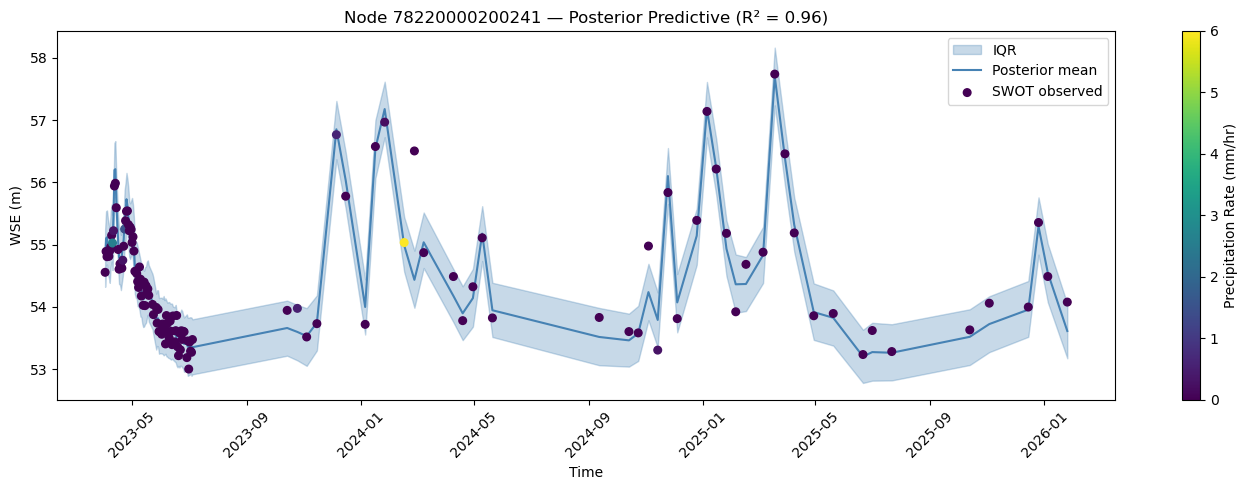

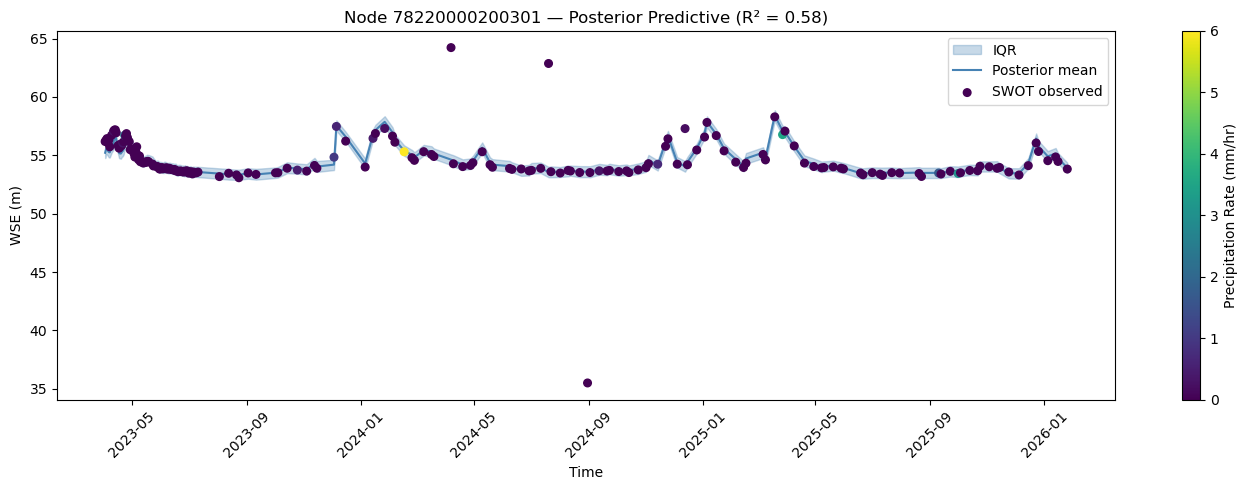

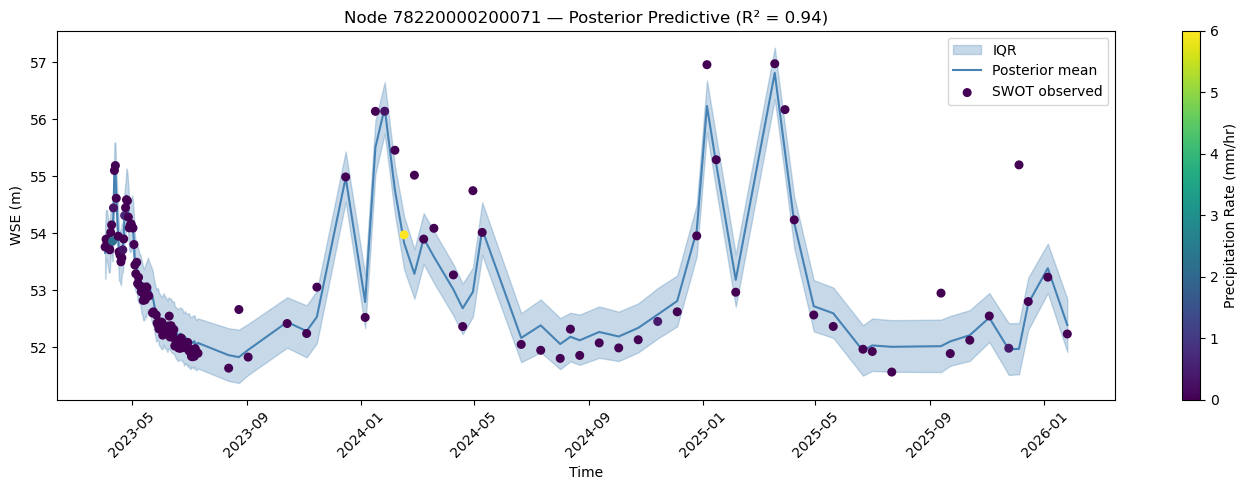

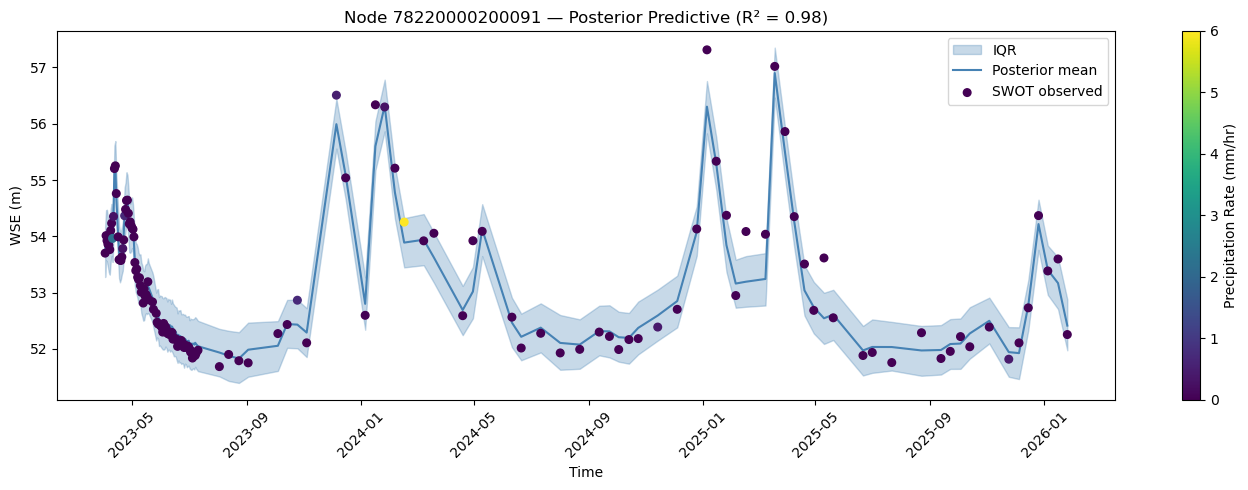

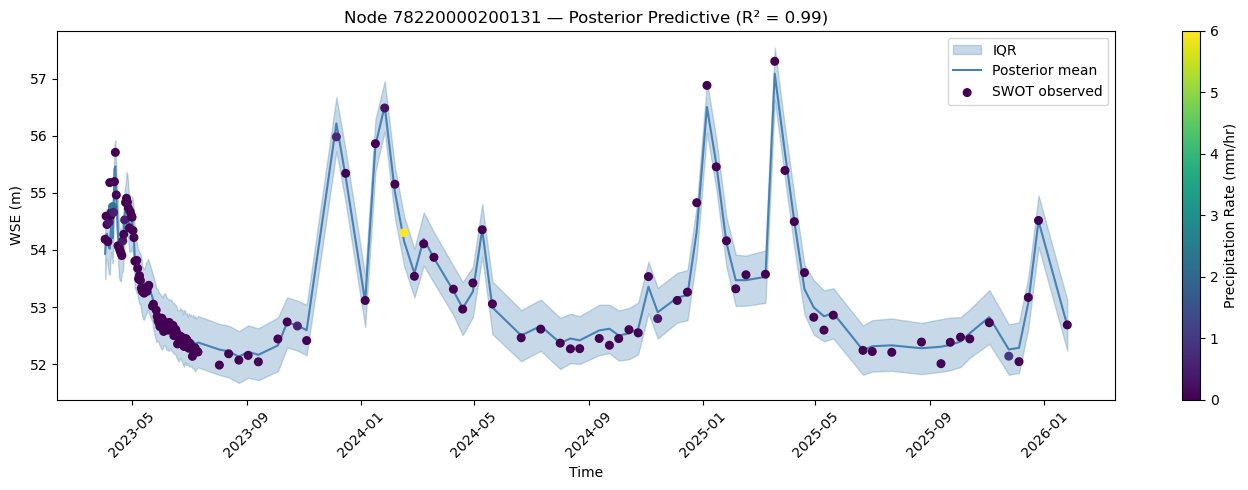

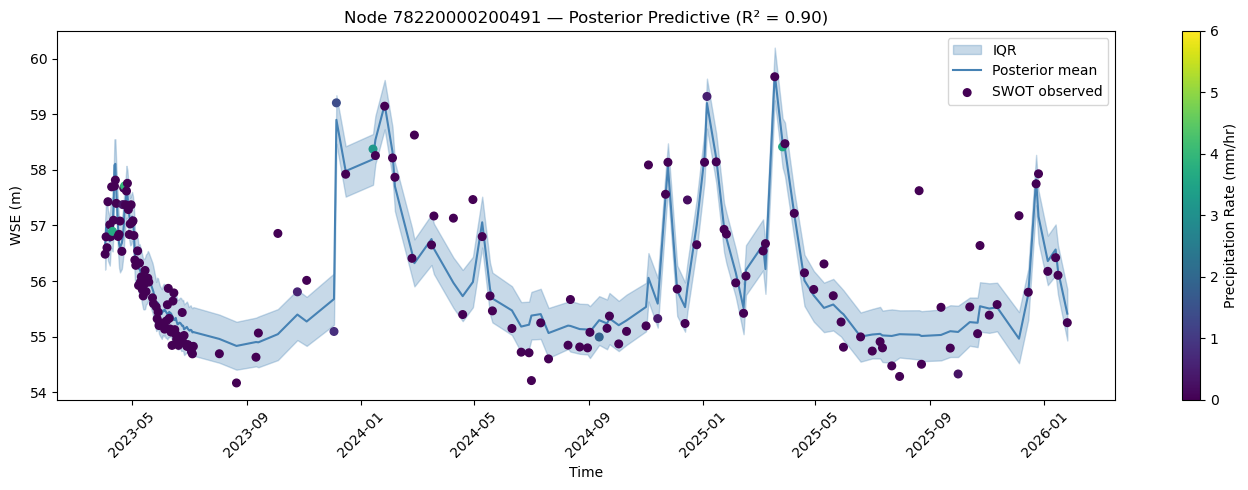

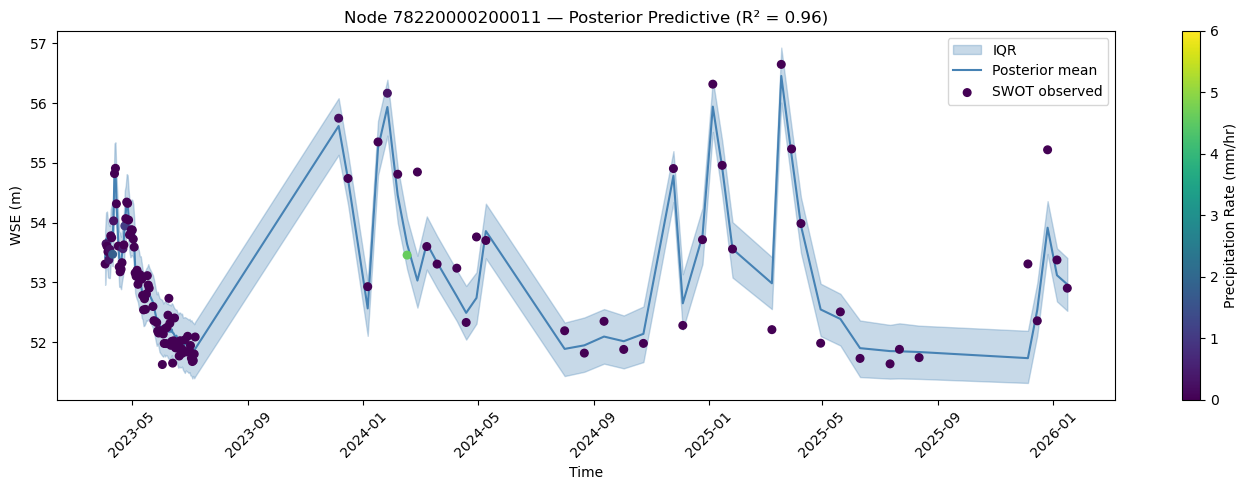

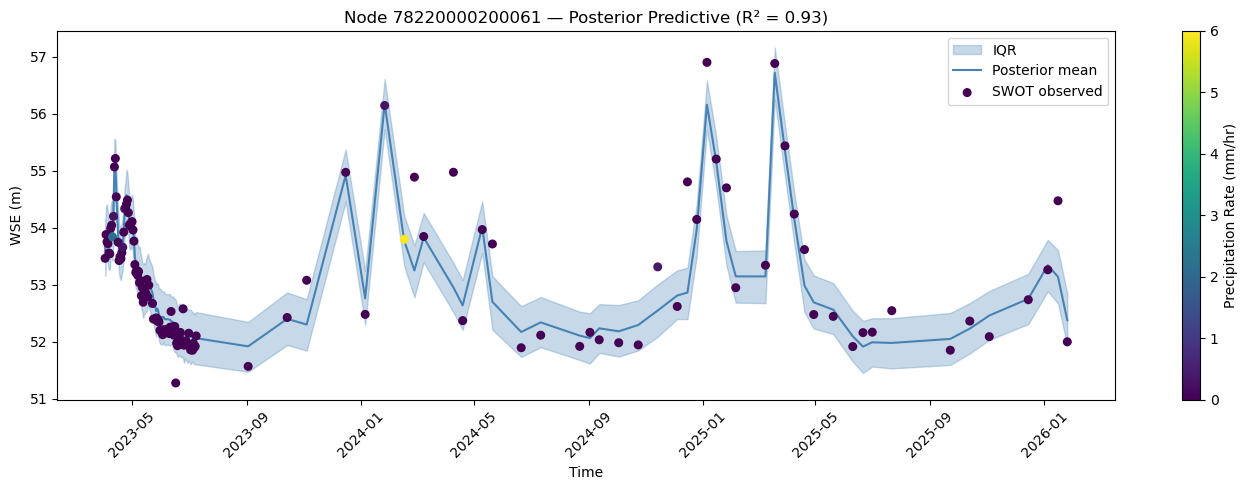

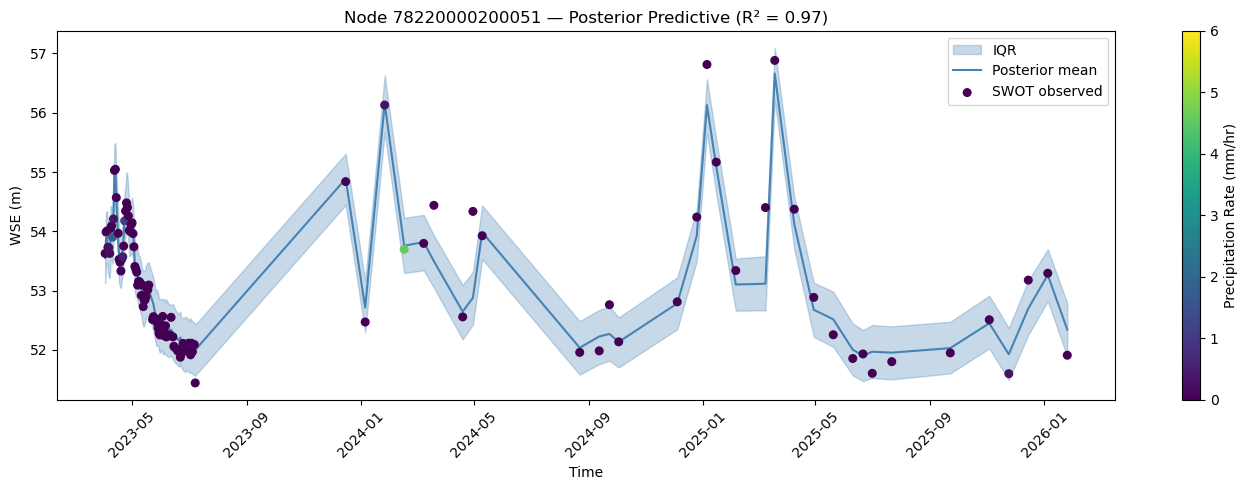

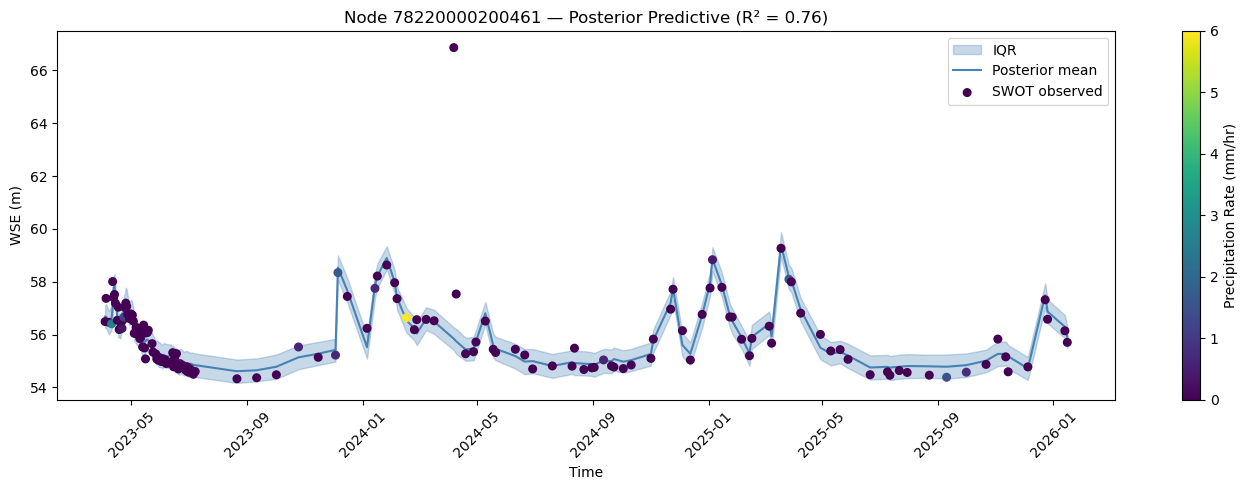

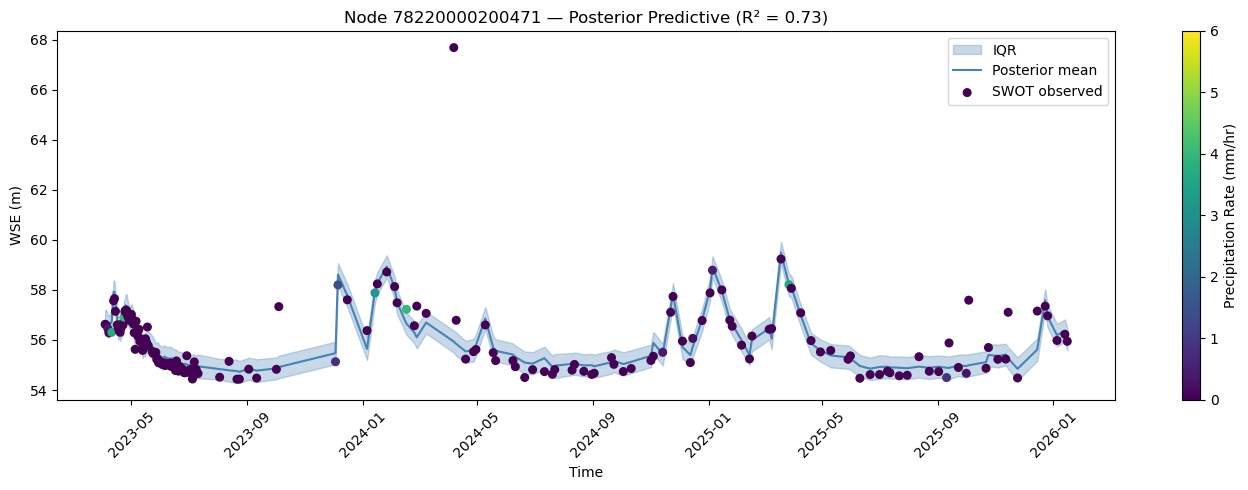

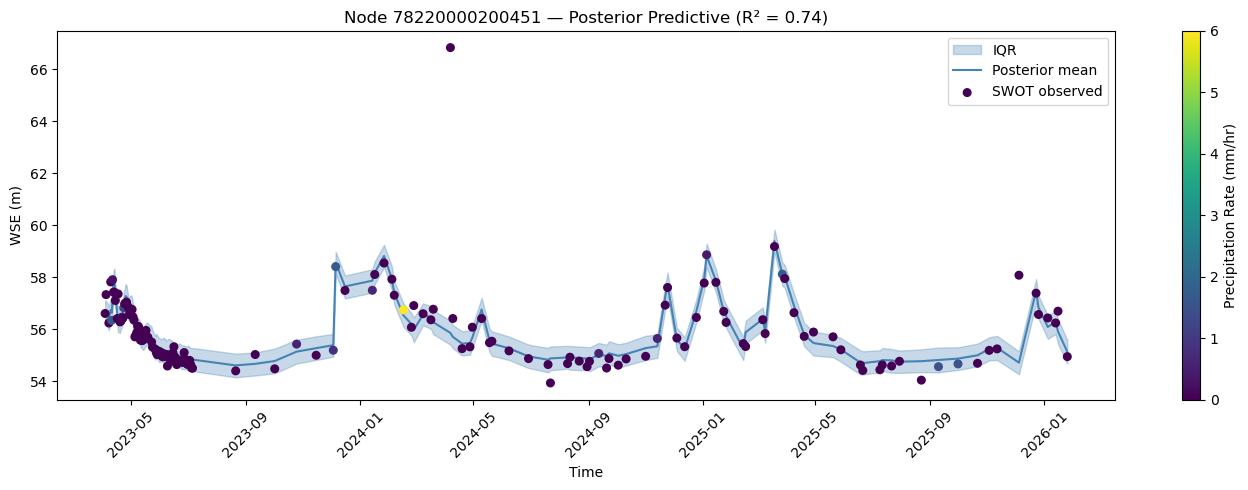

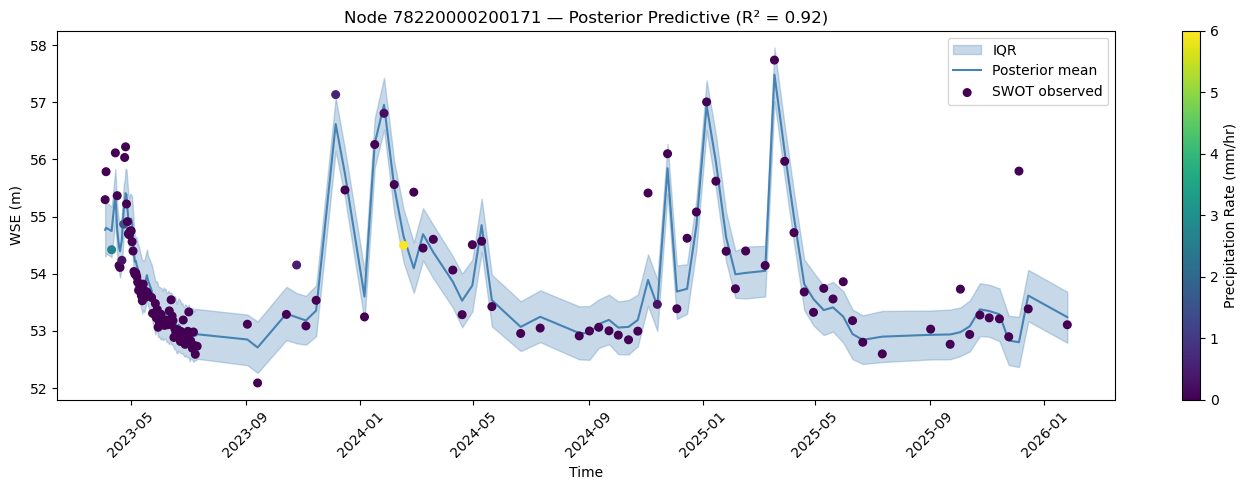

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
for node_id in combined_filtered['node_id'].unique():
    # if node_id != int(willamette_node_id):
    #     continue
    node_specific_data = combined_filtered[combined_filtered['node_id'] == int(node_id)].copy()
    node_specific_posterior_predictive = ppc.posterior_predictive.sel(wse_obs_dim_0=node_specific_data['index'].values)
    # Extract the posterior predictive values for this node
    # Shape: (chains, draws, n_obs_for_this_node)
    ppc_values = node_specific_posterior_predictive['wse_obs'].values

    # Flatten chains and draws
    # Shape: (total_samples, n_obs_for_this_node)
    ppc_flat = ppc_values.reshape(-1, ppc_values.shape[-1])

    # Compute summary statistics across samples
    mean  = ppc_flat.mean(axis=0)
    lower = np.percentile(ppc_flat, 25,  axis=0)
    upper = np.percentile(ppc_flat, 75, axis=0)

    # Get timestamps and observed values — convert to datetime
    times   = pd.to_datetime(node_specific_data['time_str'].values)
    obs_wse = node_specific_data['wse'].values
    rainfall_rate = node_specific_data['PrecipRate_00.00'].values
    gage_vals = node_specific_data['usgs_height_m_datum'].values

    # Sort by time for clean plotting
    sort_idx = np.argsort(times)
    times    = times[sort_idx]
    obs_wse  = obs_wse[sort_idx]
    mean     = mean[sort_idx]
    lower    = lower[sort_idx]
    upper    = upper[sort_idx]
    rainfall_rate = rainfall_rate[sort_idx]
    gage_vals = gage_vals[sort_idx]

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))

    # Credible interval band
    ax.fill_between(times, lower, upper, alpha=0.3, color='steelblue', label='IQR')

    # Posterior mean
    ax.plot(times, mean, color='steelblue', linewidth=1.5, label='Posterior mean')

    # Observed SWOT points
    scatter = ax.scatter(times, obs_wse, c=rainfall_rate, cmap="viridis", 
                        zorder=5, s=30, label='SWOT observed', vmin=0, vmax=6)

    # Add colorbar — use scatter handle directly
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Precipitation Rate (mm/hr)')

    # Add r2 value to title
    r2 = np.corrcoef(obs_wse, mean)[0, 1]
    ax.set_title(f'Node {node_id} — Posterior Predictive (R² = {r2:.2f})')
    # Gage values
    # ax.scatter(times, gage_vals, c='red', zorder=5, s=30, label='USGS Gage (datum adjusted)')

    ax.set_xlabel('Time')
    ax.set_ylabel('WSE (m)')
    # ax.set_title(f'Node {node_id} — Posterior Predictive')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [70]:
node_specific_data['PrecipRate_00.00']

22       0.0
91       0.0
163      0.0
186      0.0
248      0.0
        ... 
11022    0.4
11160    0.0
11267    0.0
11325    0.0
11502    0.0
Name: PrecipRate_00.00, Length: 143, dtype: float64